# Modeling EDA — Enterococcus panel for NumPyro + JAX

This notebook walks `data/processed/datatide_ground_truth.parquet` (Tier-1 CA SWRCB bacteria spine + environmental joins) and produces the panel-data inputs the hierarchical Bayesian model will consume. It follows the revised plan in `context/plan.md`:

1. **Target = Enterococcus** (marine-beach regulatory indicator). E. coli / coliform kept for secondary comparison but not modeled here.
2. **Likelihood** = censored log-normal on `log10(Result)`. Detection limits are parsed from the `Qualifier` column (`<`, `>`) and encoded as left/right censoring masks.
3. **Grain** = one row per *(station_id, sample_date)* after aggregating lab replicates by geometric mean. Prediction grain = one row per *(station_id, calendar_date)* between `TRAIN_START` and `TEST_END`.
4. **Features** = lagged rainfall (24/48/72h, 7d), dry-days-since-rain, tidal range, CDIP wave Hs/Tp, SCCOOS SST and salinity, IBWC discharge, Fourier seasonality, station and county indices.
5. **Output** = a pair of parquet files + an `.npz` with `station_idx`, `date_idx`, `X_linear`, `X_smooth`, `y_log`, `left_cens`, `right_cens`, `det_low`, `det_high`, `obs_mask`. These drop straight into a NumPyro HSGP-GAM.

No modeling is fit here — this is strictly EDA + panel construction.

In [1]:
from __future__ import annotations  

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

REPO = Path.cwd()
while REPO != REPO.parent and not (REPO / "pyproject.toml").exists():
    REPO = REPO.parent

GT_PATH = REPO / "data" / "processed" / "datatide_ground_truth.parquet"
GT_META = REPO / "data" / "processed" / "datatide_ground_truth_meta.json"
OUT_DIR = REPO / "artifacts" / "data" / "panel"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_PARAMETER = "Enterococcus"
EXCEEDANCE_MPN = 104.0
STUDY_START = pd.Timestamp("2010-01-01")
STUDY_END = pd.Timestamp("2025-12-31")
TRAIN_END = pd.Timestamp("2022-12-31")
VAL_END = pd.Timestamp("2023-12-31")

print("repo root:", REPO)
print("ground truth:", GT_PATH.relative_to(REPO), "exists =", GT_PATH.exists())
print("pandas", pd.__version__, "numpy", np.__version__)

repo root: /Users/buttz/Desktop/projects/DataTide
ground truth: data/processed/datatide_ground_truth.parquet exists = True
pandas 2.3.3 numpy 2.2.6


## 1. Load the data (rebuild vs reload)

The notebook has two entry points:

- **Rebuild mode** — runs when `data/processed/datatide_ground_truth.parquet` exists. Everything is built from scratch: raw lab rows → censoring flags → daily panel → JAX arrays. This is the path that produced `artifacts/data/panel/`.
- **Reload mode** — runs when the raw parquet is missing (e.g. `data/` is gitignored or was pruned). The saved panel pickle + metadata are read from `artifacts/data/panel/`, and the EDA cells run against the reconstructed per-observation view. Panel-construction cells short-circuit.

In rebuild mode the column-by-column loader also sidesteps a pyarrow/pandas round-trip bug on this env (nullable `Int64` columns like `Station_id` / `BeachName_id` otherwise crash `to_pandas`).

In [2]:
def read_parquet_safe(path: Path) -> pd.DataFrame:
    """Column-by-column loader that bypasses the pandas-metadata round-trip
    bug (nullable Int64 columns crash Arrow->pandas on this version combo).
    """
    import pyarrow as pa
    table = pq.read_table(path)
    data = {}
    for name in table.schema.names:
        col = table.column(name)
        arr = col.to_numpy(zero_copy_only=False)
        t = col.type
        if pa.types.is_integer(t):
            arr = pd.array(arr, dtype="Int64")
        elif pa.types.is_floating(t):
            arr = np.asarray(arr, dtype=np.float64)
        data[name] = arr
    return pd.DataFrame(data)


PANEL_PICKLE = OUT_DIR / "enterococcus_panel.pkl"
PANEL_PARQUET = OUT_DIR / "enterococcus_panel.parquet"
PANEL_NPZ = OUT_DIR / "enterococcus_panel.npz"
PANEL_META = OUT_DIR / "enterococcus_panel_meta.json"

REBUILD = GT_PATH.exists()
npz_path = PANEL_NPZ
panel_path = PANEL_PARQUET if PANEL_PARQUET.exists() else PANEL_PICKLE

if REBUILD:
    raw = read_parquet_safe(GT_PATH)
    raw["sample_date"] = pd.to_datetime(raw["sample_date"], errors="coerce")
    raw = raw.dropna(subset=["sample_date", "Station_id", "Result"]).reset_index(drop=True)
    raw["Station_id"] = raw["Station_id"].astype("int64")
    if "BeachName_id" in raw.columns:
        raw["BeachName_id"] = pd.to_numeric(raw["BeachName_id"], errors="coerce").astype("Int64")
    n_before = len(raw)
    raw = raw[(raw["sample_date"] >= STUDY_START) & (raw["sample_date"] <= STUDY_END)].reset_index(drop=True)

    meta = json.loads(GT_META.read_text()) if GT_META.exists() else {}
    print("[rebuild] reading raw ground-truth parquet")
    print(f"  dropped {n_before - len(raw):,} rows outside study window ({len(raw):,} kept)")
    print(f"  date range: {raw['sample_date'].min().date()} -> {raw['sample_date'].max().date()}")
    print(f"  stations: {raw['Station_id'].nunique():,}  counties: {raw['CountyName'].nunique()}")
    print("  layers merged:", meta.get("layers", []))
else:
    if not PANEL_PICKLE.exists() or not PANEL_META.exists():
        raise FileNotFoundError(
            "Neither raw parquet nor saved panel found.\n"
            f"  expected one of:\n    {GT_PATH}\n    {PANEL_PICKLE}"
        )
    print(f"[reload] {GT_PATH.relative_to(REPO)} missing -- loading saved panel from artifacts")
    panel = pd.read_pickle(PANEL_PICKLE)
    meta_panel = json.loads(PANEL_META.read_text())

    for col in ("is_left_cens", "is_right_cens", "is_observed"):
        if col in panel.columns:
            panel[col] = panel[col].fillna(False).astype(bool)
    panel["sample_date"] = pd.to_datetime(panel["sample_date"])
    panel["Station_id"] = panel["Station_id"].astype("int64")

    SMOOTH_FEATURES = list(meta_panel["smooth_features"])
    LINEAR_FEATURES = list(meta_panel["linear_features"])
    FEATURE_COLS = [
        "regional_ghcn_prcp_mm", "tide_range_hilo_m",
        "cdip_wave_hs_m_mean", "cdip_wave_tp_s_mean",
        "sccoos_delmar_temp_1m_c", "sccoos_delmar_salinity_1m_psu",
        "hf_current_speed_mps", "ibwc_tijuana_discharge_cms_daily_mean",
        "cce_temp_shallow_c", "cce_psal_shallow_psu",
    ]
    scalers = meta_panel.get("scalers", {})

    obs_rows = panel[panel["is_observed"]].copy()
    qualifier = np.where(obs_rows["is_left_cens"], "<",
                         np.where(obs_rows["is_right_cens"], ">", ""))
    raw = pd.DataFrame({
        "Parameter": TARGET_PARAMETER,
        "Qualifier": qualifier,
        "Result": np.power(10.0, obs_rows["log10_result"].to_numpy(dtype=float)),
        "Station_id": obs_rows["Station_id"].to_numpy(),
        "Station_Name": pd.NA,
        "CountyName": obs_rows["CountyName"].to_numpy(),
        "BeachType": obs_rows["BeachType"].to_numpy(),
        "Station_UpperLat": obs_rows["Station_UpperLat"].to_numpy(),
        "Station_UpperLon": obs_rows["Station_UpperLon"].to_numpy(),
        "sample_date": obs_rows["sample_date"].to_numpy(),
        **{c: obs_rows[c].to_numpy() for c in FEATURE_COLS if c in obs_rows.columns},
    })

    print(f"  panel rows loaded: {len(panel):,}  (observed: {int(panel['is_observed'].sum()):,})")
    print(f"  date range: {panel['sample_date'].min().date()} -> {panel['sample_date'].max().date()}")
    print(f"  stations: {panel['Station_id'].nunique():,}  counties: {panel['CountyName'].nunique()}")
    print(f"  synthesized raw (observed-only) rows: {len(raw):,}")

STATION_LABELS_PATH = OUT_DIR / "station_labels.json"

def _load_station_name_map() -> dict[int, str]:
    if not STATION_LABELS_PATH.exists():
        print(f"[warn] no station_labels.json cache; run scripts/process/reverse_geocode_stations.py")
        return {}
    raw_cache = json.loads(STATION_LABELS_PATH.read_text())
    out = {}
    for sid, info in raw_cache.items():
        nm = info.get("name")
        if nm:
            out[int(sid)] = nm
    return out

def enrich_station_names(df: pd.DataFrame, name_map: dict[int, str]) -> pd.DataFrame:
    if not name_map or "Station_id" not in df.columns:
        return df
    sid = df["Station_id"].astype("int64")
    looked_up = sid.map(name_map)
    if "Station_Name" in df.columns:
        existing = df["Station_Name"]
        df["Station_Name"] = existing.where(existing.notna() & (existing != ""), looked_up)
    else:
        df["Station_Name"] = looked_up
    return df

_station_name_map = _load_station_name_map()
raw = enrich_station_names(raw, _station_name_map)
if "panel" in dir():
    panel = enrich_station_names(panel, _station_name_map)

_n_named = int(raw["Station_Name"].notna().sum()) if "Station_Name" in raw.columns else 0
print(f"station names attached: {_n_named:,} / {len(raw):,} raw rows  "
      f"(from {len(_station_name_map):,} geocoded stations)")
if _station_name_map:
    sample = raw.drop_duplicates("Station_id").head(5)[["Station_id","Station_Name","CountyName"]]
    print(sample.to_string(index=False))

[rebuild] reading raw ground-truth parquet
  dropped 172,975 rows outside study window (1,237,167 kept)
  date range: 2010-01-04 -> 2025-12-31
  stations: 783  counties: 16
  layers merged: ['tier1_bacteria_spine', 'tier1_station_supplement', 'tier1_beach_detail_supplement', 'tier2_ghcn_regional_precip', 'tier2_coops_tidal_range', 'tier2_cdip_nearest_buoy_waves', 'tier3_sccoos_delmar_ts_regional', 'tier3_hf_radar_nearest_grid', 'tier4_cce_mooring_nearest_daily', 'tier4_bwtf_state_daily_summary_optional', 'tier5_sd_county_monthly_coastal_context', 'tier5_ibwc_tijuana_daily']
station names attached: 1,237,167 / 1,237,167 raw rows  (from 446 geocoded stations)
 Station_id        Station_Name    CountyName
        251                CBOA      Monterey
        626 Oyster Point Marina     San Mateo
        287             DPH 006   Los Angeles
        753           WP0000147 Santa Barbara
        738           WP0000007 Santa Barbara


## 2. Parameter mix — confirm Enterococcus is the defensible spine

The plan flags that only Enterococcus is reliably measured statewide at marine beaches. The rest of the notebook assumes that; this table documents the choice quantitatively so any reviewer can reproduce it.

In [3]:
param_mix = (
    raw.groupby("Parameter")
       .agg(n_rows=("Result", "size"),
            n_stations=("Station_id", "nunique"),
            n_counties=("CountyName", "nunique"),
            date_min=("sample_date", "min"),
            date_max=("sample_date", "max"))
       .sort_values("n_rows", ascending=False)
)
param_mix["pct_rows"] = (param_mix["n_rows"] / param_mix["n_rows"].sum() * 100).round(2)
param_mix

,n_rows,n_stations,n_counties,date_min,date_max,pct_rows
Parameter,,,,,,
Enterococcus,417719,778,16,2010-01-04,2025-12-31,33.76
Total Coliforms,409309,775,16,2010-01-04,2025-12-31,33.08
Fecal Coliforms,257701,667,15,2010-01-05,2025-12-31,20.83
E. Coli,152438,429,15,2010-01-04,2025-12-31,12.32


## 3. Censoring audit

MPN/CFU results are left-censored at the minimum detection limit and right-censored at IDEXX saturation (typical caps `2419.6`, `24196`). A plain Negative-Binomial or Poisson here would ignore both tails. We detect three categories:

- `left` — `Qualifier` starts with `<` **or** `Result` hits a known low detection limit (`<= 2` for Enterococcus IDEXX).
- `right` — `Qualifier` starts with `>` **or** `Result` hits a known saturation (`2419.6`, `24196`).
- `obs` — everything else (treated as point observation on the log scale).

Detection limits are stored per-row so the NumPyro likelihood can call `dist.Normal.cdf` / `1 - cdf` at the right thresholds.

In [4]:
LEFT_LIMITS_MPN = (1.0, 2.0, 10.0)
RIGHT_LIMITS_MPN = (2419.2, 2419.6, 24192.0, 24196.0)

def parse_censoring(df: pd.DataFrame) -> pd.DataFrame:
    q = df["Qualifier"].fillna("").astype(str).str.strip()
    result = df["Result"].astype(float)
    left_q = q.str.startswith("<")
    right_q = q.str.startswith(">")
    left_limit = result.where(left_q | result.isin(LEFT_LIMITS_MPN)).where(result > 0)
    right_limit = result.where(right_q | result.isin(RIGHT_LIMITS_MPN))
    is_left = left_q | result.isin(LEFT_LIMITS_MPN)
    is_right = right_q | result.isin(RIGHT_LIMITS_MPN)
    out = df.copy()
    out["is_left_cens"] = is_left.fillna(False).astype(bool)
    out["is_right_cens"] = (is_right & ~is_left).fillna(False).astype(bool)
    out["det_low"] = np.where(out["is_left_cens"], left_limit.fillna(result), np.nan)
    out["det_high"] = np.where(out["is_right_cens"], right_limit.fillna(result), np.nan)
    return out

entero = raw[raw["Parameter"] == TARGET_PARAMETER].copy()
entero = parse_censoring(entero)
entero = entero[entero["Result"] > 0].copy()
entero["log10_result"] = np.log10(entero["Result"])

cens_mix = pd.DataFrame({
    "count": [
        int(entero["is_left_cens"].sum()),
        int(entero["is_right_cens"].sum()),
        int((~entero["is_left_cens"] & ~entero["is_right_cens"]).sum()),
    ],
}, index=["left-censored", "right-censored", "uncensored"])
cens_mix["pct"] = (cens_mix["count"] / cens_mix["count"].sum() * 100).round(2)
print(f"Enterococcus rows with positive Result: {len(entero):,}")
cens_mix

Enterococcus rows with positive Result: 416,274


,count,pct
left-censored,262707,63.11
right-censored,5623,1.35
uncensored,147944,35.54


## 4. Target distribution and exceedance rate

The regulatory single-sample threshold for marine Enterococcus is **104 MPN/100 mL**. Before modeling, two things need justification: (a) why we model the *log10* concentration rather than raw counts, and (b) what the unconditional exceedance rate looks like — the base rate any classifier must beat.

**Why log10?** Four reasons, all visible in the diagnostic below:

1. **Dynamic range.** Raw counts span 0 → 24,000+ MPN/100 mL — four-plus orders of magnitude. On a linear axis 99% of the mass piles up at zero and the storm days look like outliers. On a log axis the distribution is roughly bell-shaped.
2. **Mechanism is multiplicative.** Bacterial decay is first-order (`N(t) = N₀·e^(-kt)`), sunlight die-off is log-linear in UV, dilution is proportional. These are additive on log scale — exactly what a GAM / HSGP smooth wants.
3. **The regulatory world already uses log.** AB 411 and EPA BAV criteria are stated as geometric means and ratios because log is the right space for this quantity; `log10(104) ≈ 2.017` is the fixed line we evaluate against.
4. **Censored likelihood is natural on log scale.** Censored log-normal has a closed-form CDF that makes left-/right-censored observations trivial; counts would require a censored NB with no such convenience.

/var/folders/6l/fh4ck8px62x4x7vp3j9kjr6h0000gn/T/ipykernel_40308/3983987581.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1, 1].boxplot([_log, np.log10(_raw_clip)], labels=["stored log10", "log10 of raw"], vert=True)


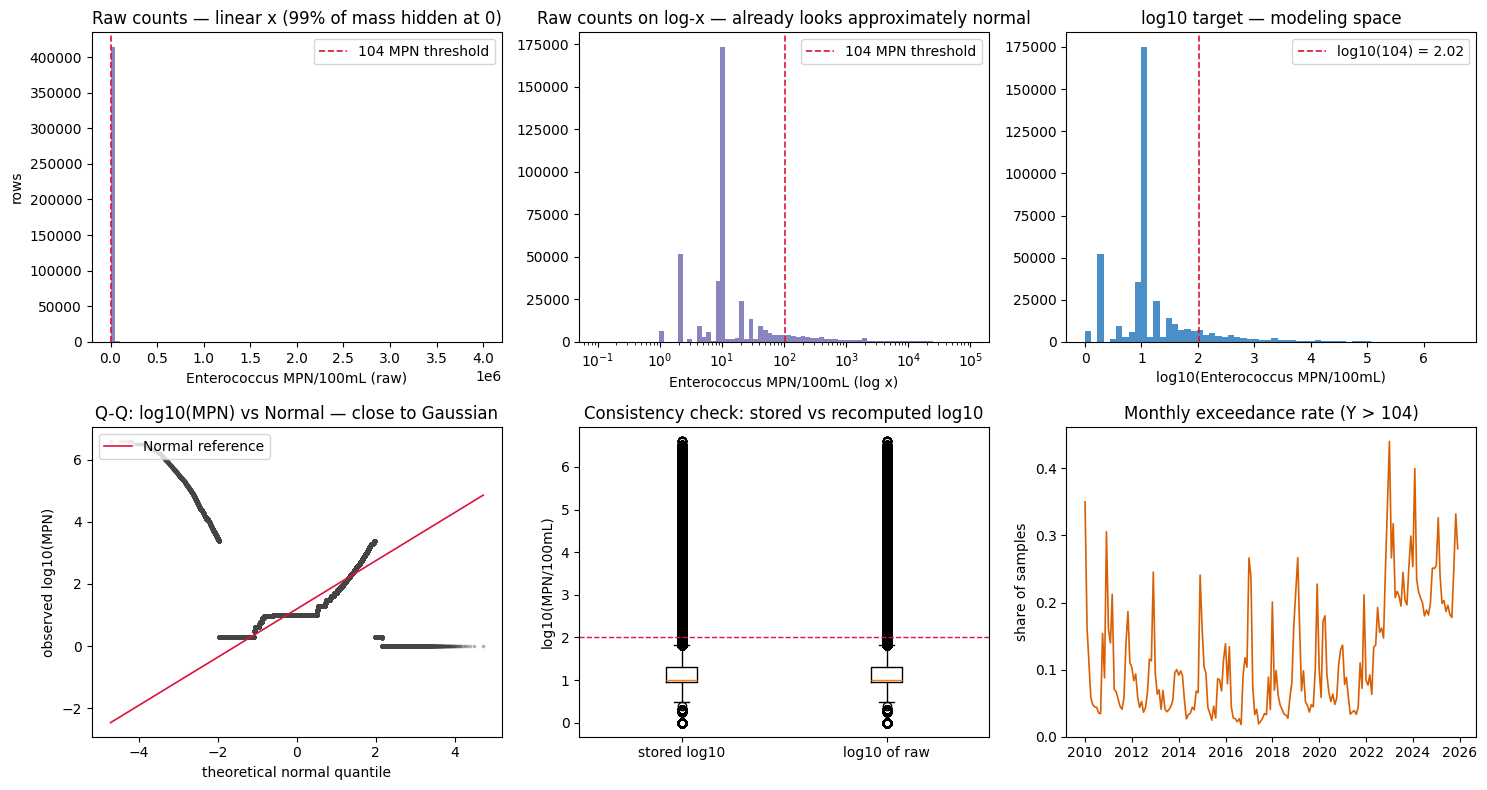

Overall exceedance rate (base rate to beat): 11.48%

raw count distribution summary (MPN/100mL):
count     416274.00
mean        2214.13
std        48888.77
min            1.00
25%            9.00
50%           10.00
75%           20.00
90%          140.00
99%        15300.00
max      4000000.00

log10 distribution summary:
count    416274.000
mean          1.197
std           0.777
min           0.000
10%           0.301
25%           0.954
50%           1.000
75%           1.301
90%           2.146
max           6.602

shape statistics (normal reference: skew=0, excess kurtosis=0):
  raw MPN/100mL     skew=+46.01   excess kurt=+2640.30  <- heavily right-skewed, extreme tails
  log10(MPN/100mL)  skew=+2.03   excess kurt=+6.20  <- close to Gaussian

(exact normality isn't required -- censoring + a mixture of stations will bend the tails; the point is that log10 is vastly closer to Gaussian than raw, so the normal-based (censored-log-normal) likelihood is defensible.)


In [5]:
from math import erf, sqrt

def _norm_ppf(p):
    """Standard-normal inverse CDF via rational Beasley-Springer-Moro (stdlib-only)."""
    p = np.asarray(p, dtype=float)
    a = [-3.969683028665376e+01, 2.209460984245205e+02, -2.759285104469687e+02,
         1.383577518672690e+02, -3.066479806614716e+01, 2.506628277459239e+00]
    b = [-5.447609879822406e+01, 1.615858368580409e+02, -1.556989798598866e+02,
         6.680131188771972e+01, -1.328068155288572e+01]
    c = [-7.784894002430293e-03, -3.223964580411365e-01, -2.400758277161838e+00,
         -2.549732539343734e+00, 4.374664141464968e+00, 2.938163982698783e+00]
    d = [7.784695709041462e-03, 3.224671290700398e-01, 2.445134137142996e+00,
         3.754408661907416e+00]
    plow, phigh = 0.02425, 1 - 0.02425
    q = np.where(p < plow, np.sqrt(-2 * np.log(p)),
        np.where(p > phigh, np.sqrt(-2 * np.log(1 - p)), p - 0.5))
    r = np.where((p >= plow) & (p <= phigh), q * q, 0.0)
    out = np.where((p >= plow) & (p <= phigh),
        (((((a[0]*r + a[1])*r + a[2])*r + a[3])*r + a[4])*r + a[5]) * q /
        (((((b[0]*r + b[1])*r + b[2])*r + b[3])*r + b[4])*r + 1),
        np.where(p < plow,
            -(((((c[0]*q + c[1])*q + c[2])*q + c[3])*q + c[4])*q + c[5]) /
             ((((d[0]*q + d[1])*q + d[2])*q + d[3])*q + 1),
             (((((c[0]*q + c[1])*q + c[2])*q + c[3])*q + c[4])*q + c[5]) /
             ((((d[0]*q + d[1])*q + d[2])*q + d[3])*q + 1)))
    return out

_raw = entero["Result"].astype(float).to_numpy()
_log = entero["log10_result"].astype(float).to_numpy()
_raw_clip = np.clip(_raw, 1e-1, None)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

ax[0, 0].hist(_raw, bins=80, color="#7570b3", alpha=0.85)
ax[0, 0].axvline(EXCEEDANCE_MPN, color="crimson", lw=1.2, ls="--", label="104 MPN threshold")
ax[0, 0].set_xlabel("Enterococcus MPN/100mL (raw)")
ax[0, 0].set_ylabel("rows")
ax[0, 0].set_title("Raw counts — linear x (99% of mass hidden at 0)")
ax[0, 0].legend()

ax[0, 1].hist(_raw_clip, bins=np.logspace(-1, 5, 80), color="#7570b3", alpha=0.85)
ax[0, 1].axvline(EXCEEDANCE_MPN, color="crimson", lw=1.2, ls="--", label="104 MPN threshold")
ax[0, 1].set_xscale("log")
ax[0, 1].set_xlabel("Enterococcus MPN/100mL (log x)")
ax[0, 1].set_title("Raw counts on log-x — already looks approximately normal")
ax[0, 1].legend()

ax[0, 2].hist(_log, bins=60, color="#2b7cbf", alpha=0.85)
ax[0, 2].axvline(np.log10(EXCEEDANCE_MPN), color="crimson", lw=1.2, ls="--",
                 label=f"log10({EXCEEDANCE_MPN:.0f}) = {np.log10(EXCEEDANCE_MPN):.2f}")
ax[0, 2].set_xlabel("log10(Enterococcus MPN/100mL)")
ax[0, 2].set_title("log10 target — modeling space")
ax[0, 2].legend()

_qq = np.sort(_log[np.isfinite(_log)])
_n_qq = len(_qq)
_theor = _norm_ppf((np.arange(1, _n_qq + 1) - 0.5) / _n_qq)
_theor_std = _theor * _qq.std() + _qq.mean()
ax[1, 0].scatter(_theor, _qq, s=3, alpha=0.3, color="#444")
_lo, _hi = _theor.min(), _theor.max()
ax[1, 0].plot([_lo, _hi], [_lo * _qq.std() + _qq.mean(), _hi * _qq.std() + _qq.mean()],
              color="crimson", lw=1.2, label="Normal reference")
ax[1, 0].set_xlabel("theoretical normal quantile")
ax[1, 0].set_ylabel("observed log10(MPN)")
ax[1, 0].set_title("Q-Q: log10(MPN) vs Normal — close to Gaussian")
ax[1, 0].legend(loc="upper left")

ax[1, 1].boxplot([_log, np.log10(_raw_clip)], labels=["stored log10", "log10 of raw"], vert=True)
ax[1, 1].axhline(np.log10(EXCEEDANCE_MPN), color="crimson", lw=1.0, ls="--")
ax[1, 1].set_ylabel("log10(MPN/100mL)")
ax[1, 1].set_title("Consistency check: stored vs recomputed log10")

monthly = (entero.assign(month=entero["sample_date"].dt.to_period("M"))
                  .groupby("month")
                  .agg(n=("Result", "size"),
                       exc=("Result", lambda s: (s > EXCEEDANCE_MPN).mean()))
                  .reset_index())
monthly["month_ts"] = monthly["month"].dt.to_timestamp()
ax[1, 2].plot(monthly["month_ts"], monthly["exc"], color="#d95f02", lw=1.2)
ax[1, 2].set_title(f"Monthly exceedance rate (Y > {EXCEEDANCE_MPN:.0f})")
ax[1, 2].set_ylabel("share of samples")
ax[1, 2].set_ylim(0, None)

fig.tight_layout()
plt.show()

overall_exc = float((_raw > EXCEEDANCE_MPN).mean())
print(f"Overall exceedance rate (base rate to beat): {overall_exc:.2%}")
print()
print("raw count distribution summary (MPN/100mL):")
print(pd.Series(_raw).describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).round(2).to_string())
print()
print("log10 distribution summary:")
print(pd.Series(_log).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(3).to_string())

def _skew_kurt(x):
    x = x[np.isfinite(x)]
    mu, sd = x.mean(), x.std()
    if sd == 0:
        return 0.0, 0.0
    z = (x - mu) / sd
    return float((z ** 3).mean()), float((z ** 4).mean() - 3.0)

_skew_raw, _kurt_raw = _skew_kurt(_raw)
_skew_log, _kurt_log = _skew_kurt(_log)
print("\nshape statistics (normal reference: skew=0, excess kurtosis=0):")
print(f"  raw MPN/100mL     skew={_skew_raw:+.2f}   excess kurt={_kurt_raw:+.2f}  "
      f"<- heavily right-skewed, extreme tails")
print(f"  log10(MPN/100mL)  skew={_skew_log:+.2f}   excess kurt={_kurt_log:+.2f}  "
      f"<- close to Gaussian")
print("\n(exact normality isn't required -- censoring + a mixture of stations will bend the tails; "
      "the point is that log10 is vastly closer to Gaussian than raw, so the normal-based "
      "(censored-log-normal) likelihood is defensible.)")

## 5. Seasonal structure — why the Phase B naive baseline is seasonal

California's Mediterranean climate produces a pronounced annual cycle in coastal bacteria counts, driven by the wet-winter / dry-summer rainfall cycle and by UV intensity. Before moving on to station coverage and feature engineering, this section confirms visually that the distribution of `log10(MPN)` **shifts materially with month** — enough that a pooled-mean baseline would be conceding an obvious source of predictive signal.

Motivation for the downstream modeling plan: the Phase B naive baseline uses `mean(counts | month)` on the training window, not the grand mean. The EDA below measures how much variance this month-conditioning alone explains, and shows the inverse count profile between a wet-season month (December) and a dry-season month (June) directly.

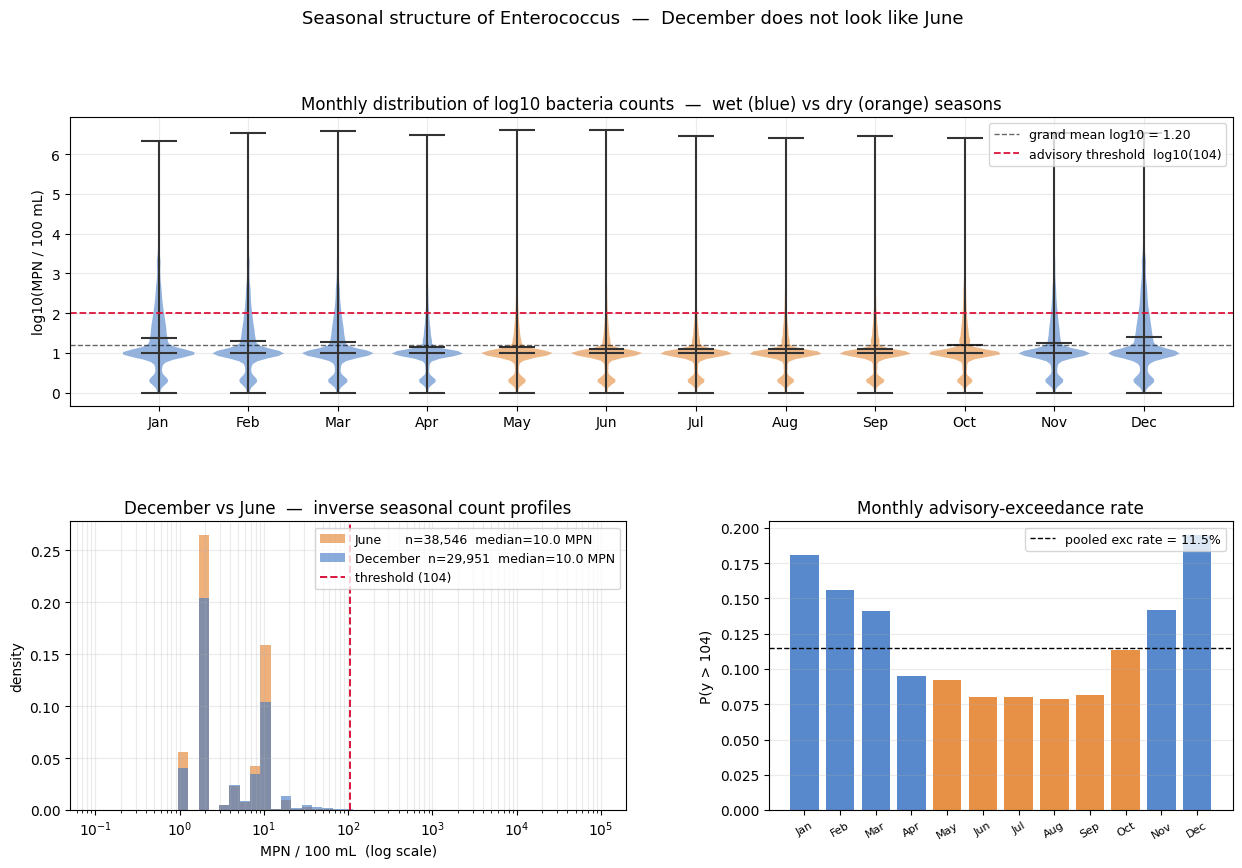

SEASONAL STRUCTURE  —  justification for month-conditional Phase B baseline
peak month    : 12 (Dec)   mean log10 = 1.39   ->  median MPN ~     25
trough month  :  6 (Jun)   mean log10 = 1.10   ->  median MPN ~     13
peak-to-trough log10 range: 0.29  ->  1.9x fold change in the median count between peak and trough months

December median count   :   10.0 MPN   (exceedance rate  19.5%)
June     median count   :   10.0 MPN   (exceedance rate  8.0%)
Dec/Jun fold ratio      :    1.0x   ->  winter counts are roughly 1.0x higher than summer counts at the same beach, on typical days

variance of log10_result explained by month-only predictor: 1.6%
  pooled-mean baseline:           SD(residual) = 0.777  log10
  month-conditional baseline:     SD(residual) = 0.771  log10
  conditioning on month shrinks residual SD by 0.8%  at zero modeling cost

=> The Phase B 'naive' baseline in the modeling plan uses mean(counts | month)
   from the training window, not the grand mean. This raises the floor 

In [6]:
_e = entero.copy()
_e = _e[np.isfinite(_e["log10_result"])]
_e["month"] = _e["sample_date"].dt.month

months = list(range(1, 13))
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
wet_months = {11, 12, 1, 2, 3, 4}

fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1.0], height_ratios=[1, 1],
                      hspace=0.40, wspace=0.28)

ax1 = fig.add_subplot(gs[0, :])
data_by_month = [_e.loc[_e["month"] == m, "log10_result"].to_numpy() for m in months]
violin = ax1.violinplot(data_by_month, positions=months, widths=0.8,
                        showmeans=True, showmedians=True)
for i, body in enumerate(violin["bodies"]):
    body.set_facecolor("#3a75c4" if months[i] in wet_months else "#e37e25")
    body.set_alpha(0.55)
for key in ["cmeans", "cmedians", "cbars", "cmaxes", "cmins"]:
    if key in violin:
        violin[key].set_color("#333")
ax1.axhline(_e["log10_result"].mean(), color="k", linestyle="--", lw=1, alpha=0.6,
            label=f"grand mean log10 = {_e['log10_result'].mean():.2f}")
ax1.axhline(np.log10(EXCEEDANCE_MPN), color="crimson", linestyle="--", lw=1.3,
            label=f"advisory threshold  log10({int(EXCEEDANCE_MPN)})")
ax1.set_xticks(months)
ax1.set_xticklabels(month_names)
ax1.set_ylabel("log10(MPN / 100 mL)")
ax1.set_title("Monthly distribution of log10 bacteria counts  —  wet (blue) vs dry (orange) seasons")
ax1.legend(loc="upper right", fontsize=9)
ax1.grid(True, alpha=0.25)

ax2 = fig.add_subplot(gs[1, 0])
dec_counts = (10 ** _e.loc[_e["month"] == 12, "log10_result"]).to_numpy()
jun_counts = (10 ** _e.loc[_e["month"] == 6,  "log10_result"]).to_numpy()
bins = np.logspace(-1, 5, 50)
ax2.hist(jun_counts, bins=bins, alpha=0.60, color="#e37e25",
         label=f"June      n={len(jun_counts):,}  median={np.median(jun_counts):.1f} MPN",
         density=True)
ax2.hist(dec_counts, bins=bins, alpha=0.60, color="#3a75c4",
         label=f"December  n={len(dec_counts):,}  median={np.median(dec_counts):.1f} MPN",
         density=True)
ax2.axvline(EXCEEDANCE_MPN, color="crimson", linestyle="--", lw=1.4,
            label=f"threshold ({int(EXCEEDANCE_MPN)})")
ax2.set_xscale("log")
ax2.set_xlabel("MPN / 100 mL  (log scale)")
ax2.set_ylabel("density")
ax2.set_title("December vs June  —  inverse seasonal count profiles")
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(True, which="both", alpha=0.25)

ax3 = fig.add_subplot(gs[1, 1])
_monthly_exc = _e.assign(exc=(10 ** _e["log10_result"] > EXCEEDANCE_MPN).astype(int)) \
                 .groupby("month")["exc"].mean()
_colors = ["#3a75c4" if m in wet_months else "#e37e25" for m in _monthly_exc.index]
ax3.bar(_monthly_exc.index, _monthly_exc.to_numpy(), color=_colors, alpha=0.85)
_overall_exc = (10 ** _e["log10_result"] > EXCEEDANCE_MPN).mean()
ax3.axhline(_overall_exc, color="k", linestyle="--", lw=1,
            label=f"pooled exc rate = {_overall_exc:.1%}")
ax3.set_xticks(months)
ax3.set_xticklabels(month_names, rotation=30, fontsize=8)
ax3.set_ylabel("P(y > 104)")
ax3.set_title("Monthly advisory-exceedance rate")
ax3.legend(loc="upper right", fontsize=9)
ax3.grid(True, axis="y", alpha=0.25)

plt.suptitle("Seasonal structure of Enterococcus  —  December does not look like June",
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

_monthly_mean_log10 = _e.groupby("month")["log10_result"].mean()
_peak_m = int(_monthly_mean_log10.idxmax())
_trough_m = int(_monthly_mean_log10.idxmin())
_peak_lg = float(_monthly_mean_log10.max())
_trough_lg = float(_monthly_mean_log10.min())
_fold_peak_trough = 10 ** (_peak_lg - _trough_lg)

_dec_median_c = float(np.median(dec_counts))
_jun_median_c = float(np.median(jun_counts))
_dec_exc_c = float((dec_counts > EXCEEDANCE_MPN).mean())
_jun_exc_c = float((jun_counts > EXCEEDANCE_MPN).mean())
_fold_dec_jun = _dec_median_c / _jun_median_c if _jun_median_c > 0 else float("nan")

_resid_pooled = _e["log10_result"] - _e["log10_result"].mean()
_resid_monthly = _e["log10_result"] - _e.groupby("month")["log10_result"].transform("mean")
_var_explained = 1 - (_resid_monthly.var() / _resid_pooled.var())
_sd_shrink = (_resid_pooled.std() - _resid_monthly.std()) / _resid_pooled.std()

print("=" * 72)
print("SEASONAL STRUCTURE  —  justification for month-conditional Phase B baseline")
print("=" * 72)
print(f"peak month    : {_peak_m:>2d} ({month_names[_peak_m - 1]})   mean log10 = {_peak_lg:.2f}"
      f"   ->  median MPN ~ {10 ** _peak_lg:>6.0f}")
print(f"trough month  : {_trough_m:>2d} ({month_names[_trough_m - 1]})   mean log10 = {_trough_lg:.2f}"
      f"   ->  median MPN ~ {10 ** _trough_lg:>6.0f}")
print(f"peak-to-trough log10 range: {_peak_lg - _trough_lg:.2f}"
      f"  ->  {_fold_peak_trough:.1f}x fold change in the median count between peak and trough months")
print()
print(f"December median count   : {_dec_median_c:>6.1f} MPN   (exceedance rate  {_dec_exc_c:.1%})")
print(f"June     median count   : {_jun_median_c:>6.1f} MPN   (exceedance rate  {_jun_exc_c:.1%})")
print(f"Dec/Jun fold ratio      : {_fold_dec_jun:>6.1f}x   ->  winter counts are roughly {_fold_dec_jun:.1f}x"
      " higher than summer counts at the same beach, on typical days")
print()
print(f"variance of log10_result explained by month-only predictor: {_var_explained:.1%}")
print(f"  pooled-mean baseline:           SD(residual) = {_resid_pooled.std():.3f}  log10")
print(f"  month-conditional baseline:     SD(residual) = {_resid_monthly.std():.3f}  log10")
print(f"  conditioning on month shrinks residual SD by {_sd_shrink:.1%}  at zero modeling cost")
print()
print("=> The Phase B 'naive' baseline in the modeling plan uses mean(counts | month)")
print("   from the training window, not the grand mean. This raises the floor to a")
print("   meaningful minimum so that downstream models earn their complexity.")


## 6. Station and county coverage

The hierarchical model pools across station → county. We need enough samples per station to identify the station random effect; otherwise pooling does the work and we should treat sparse stations as cold-start.

station sample-count quantiles:
0.10      7.0
0.25    147.5
0.50    502.5
0.75    744.0
0.90    926.1
Name: n_samples, dtype: float64

top counties by row volume:
CountyName
Orange             117264
San Diego           81553
Los Angeles         80886
Ventura             21183
San Mateo           17028
San Francisco       14686
Santa Cruz          14483
Long Beach City     14109
San Luis Obispo     13859
Santa Barbara       11885
dtype: int64

top 12 most-sampled beaches (by row count):
 Station_id Station_Name  CountyName  n_samples  exc_rate  span_days
        450      SMB-3-3 Los Angeles       3672  0.231754       5467
        452      SMB-3-5 Los Angeles       3642  0.070566       5465
        447     SMB-1-18 Los Angeles       3638  0.195437       5467
        437     SMB-MC-2 Los Angeles       3636  0.183718       5467
        449      SMB-2-7 Los Angeles       3636  0.152365       5467
        451      SMB-3-4 Los Angeles       3618  0.166943       5467
        436        CB-02 

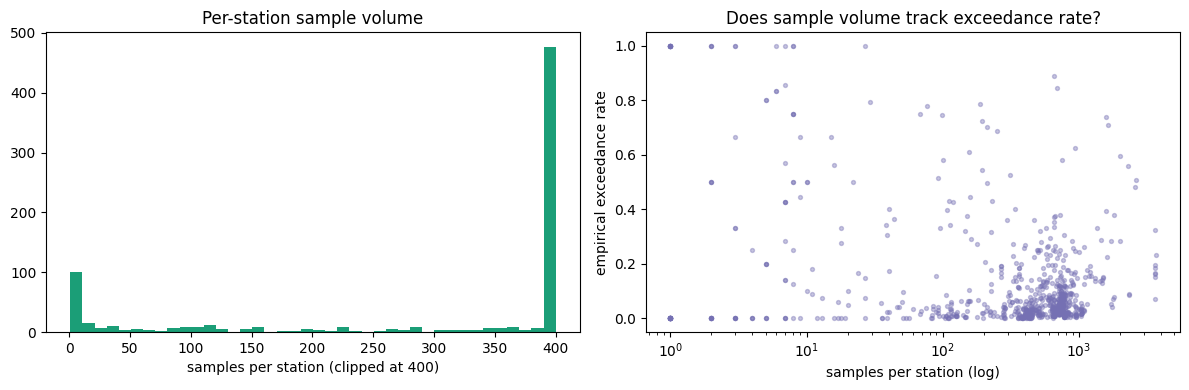

,Station_id,Station_Name,CountyName,n_samples,date_min,date_max,exc_rate,span_days
0,1,0,Orange,1736,2010-08-30,2025-12-30,0.051843,5601
1,2,1000,Ventura,735,2010-11-08,2025-12-29,0.072109,5530
2,3,10000,Ventura,703,2010-11-08,2025-10-27,0.046942,5467
3,5,1050,Ventura,110,2011-04-04,2014-10-27,0.018182,1302
4,6,1100,Ventura,279,2015-03-16,2025-10-27,0.014337,3878


In [7]:
_station_group_cols = [c for c in ["Station_id", "Station_Name", "CountyName"]
                       if c in entero.columns and entero[c].notna().any()]
per_station = (entero.groupby(_station_group_cols, dropna=False)
                      .agg(n_samples=("Result", "size"),
                           date_min=("sample_date", "min"),
                           date_max=("sample_date", "max"),
                           exc_rate=("Result", lambda s: (s > EXCEEDANCE_MPN).mean()))
                      .reset_index())
per_station["span_days"] = (per_station["date_max"] - per_station["date_min"]).dt.days

print("station sample-count quantiles:")
print(per_station["n_samples"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(1))
print()
print("top counties by row volume:")
print(entero.groupby("CountyName").size().sort_values(ascending=False).head(10))

print()
print("top 12 most-sampled beaches (by row count):")
_label_cols = [c for c in ["Station_id", "Station_Name", "CountyName"] if c in per_station.columns]
print(per_station.sort_values("n_samples", ascending=False)
                 .head(12)[_label_cols + ["n_samples", "exc_rate", "span_days"]]
                 .to_string(index=False))

print()
print("stations with <= 5 observations (candidates for hierarchical pooling to carry the weight):")
_sparse = per_station[per_station["n_samples"] <= 5]
print(f"  {len(_sparse):,} stations  "
      f"(~{len(_sparse) / max(len(per_station), 1):.0%} of all beaches)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(per_station["n_samples"].clip(upper=400), bins=40, color="#1b9e77")
ax[0].set_xlabel("samples per station (clipped at 400)")
ax[0].set_title("Per-station sample volume")

ax[1].scatter(per_station["n_samples"], per_station["exc_rate"], s=8, alpha=0.4, color="#7570b3")
ax[1].set_xscale("log")
ax[1].set_xlabel("samples per station (log)")
ax[1].set_ylabel("empirical exceedance rate")
ax[1].set_title("Does sample volume track exceedance rate?")
fig.tight_layout()
plt.show()
per_station.head()

## 7. Sample cadence — confirms “not weekly”

The plan calls out that treating sampling as weekly is wrong; AB 411 drives daily cadence in summer and monthly off-season. The cadence histogram here justifies treating the Bayesian model as a state-space problem: latent daily process, observation only on sample days.

between-sample gap (days) quantiles:
0.10     1.0
0.25     4.0
0.50     7.0
0.75     7.0
0.90     8.0
0.99    42.0
Name: sample_date, dtype: float64


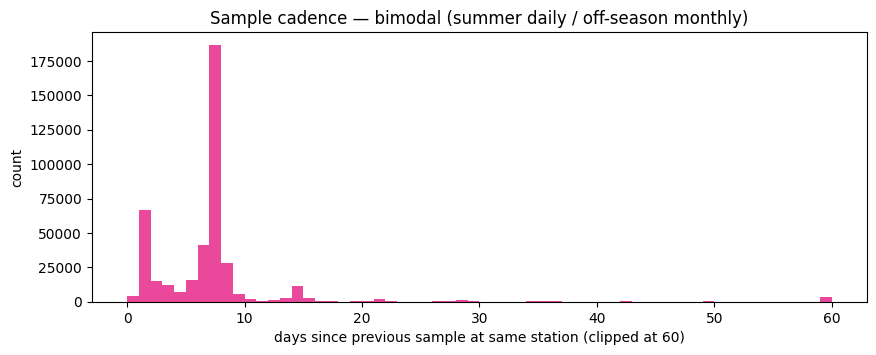

In [8]:
gap = (entero.sort_values(["Station_id", "sample_date"])
              .groupby("Station_id")["sample_date"]
              .diff()
              .dt.days
              .dropna())

print("between-sample gap (days) quantiles:")
print(gap.quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).round(1))

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(gap.clip(upper=60), bins=60, color="#e7298a", alpha=0.85)
ax.set_xlabel("days since previous sample at same station (clipped at 60)")
ax.set_ylabel("count")
ax.set_title("Sample cadence — bimodal (summer daily / off-season monthly)")
plt.show()

## 8. Environmental feature coverage

Many environmental joins are regional or NRT-window-limited (see `context/GROUND_TRUTH_SCHEMA.md`). We tabulate per-row non-null share so the modeling config knows which smooths are viable statewide vs regional only. Sparse features stay in the design matrix with a dedicated `is_missing` indicator rather than being silently imputed.

In [9]:
FEATURE_COLS = [
    "regional_ghcn_prcp_mm",
    "tide_range_hilo_m",
    "cdip_wave_hs_m_mean",
    "cdip_wave_tp_s_mean",
    "sccoos_delmar_temp_1m_c",
    "sccoos_delmar_salinity_1m_psu",
    "hf_current_speed_mps",
    "ibwc_tijuana_discharge_cms_daily_mean",
    "cce_temp_shallow_c",
    "cce_psal_shallow_psu",
]

cov = (entero[FEATURE_COLS]
         .notna()
         .mean()
         .sort_values(ascending=False)
         .rename("non_null_share")
         .to_frame())
cov["n_non_null"] = entero[FEATURE_COLS].notna().sum().astype(int)
print("feature coverage on Enterococcus rows:")
print(cov)

log_cols = ["log10_result"] + [c for c in FEATURE_COLS if entero[c].notna().mean() > 0.05]
corr = entero[log_cols].corr(method="spearman")
print("\nSpearman corr vs log10(Enterococcus):")
print(corr["log10_result"].drop("log10_result").sort_values(key=lambda s: s.abs(), ascending=False))

feature coverage on Enterococcus rows:
                                       non_null_share  n_non_null
regional_ghcn_prcp_mm                        1.000000      416274
tide_range_hilo_m                            0.999846      416210
sccoos_delmar_temp_1m_c                      0.504841      210152
sccoos_delmar_salinity_1m_psu                0.504819      210143
cce_temp_shallow_c                           0.071150       29618
cce_psal_shallow_psu                         0.071150       29618
cdip_wave_hs_m_mean                          0.053246       22165
cdip_wave_tp_s_mean                          0.053246       22165
hf_current_speed_mps                         0.000000           0
ibwc_tijuana_discharge_cms_daily_mean        0.000000           0

Spearman corr vs log10(Enterococcus):
cdip_wave_tp_s_mean             -0.188868
cce_temp_shallow_c              -0.156154
regional_ghcn_prcp_mm            0.148918
sccoos_delmar_temp_1m_c         -0.102203
tide_range_hilo_m           

## 9. Aggregate lab replicates → one row per (station, date)

Multiple `RESULTS id` per station/day are replicate lab aliquots. The statistically-correct summary on the log scale is the geometric mean (equivalently, arithmetic mean of `log10`). We also propagate censoring: a day counts as left-censored only if *all* replicates were left-censored; ditto right. If the day mixes censored and uncensored reads, we keep the uncensored mean and drop the indicator.

In [10]:
KEY = ["Station_id", "sample_date"]


def _collapse_replicates(entero: pd.DataFrame) -> pd.DataFrame:
    """Vectorised replicate-collapse.

    For each (station, date) group:
    - `n_replicates`   = group size
    - `is_left_cens`   = True iff *all* rows in the group are left-censored
    - `is_right_cens`  = True iff *all* rows are right-censored
    - `log10_result`   = mean over non-censored rows in mixed groups, else mean
                        over all rows in homogeneous groups
    - `det_low`        = max detection floor over all left-censored rows
                         (only meaningful when `is_left_cens=True`)
    - `det_high`       = min detection ceiling over right-censored rows
                         (only meaningful when `is_right_cens=True`)
    - station metadata (County / lat / lon / BeachType) = first row's value

    Vectorised version of the per-group Python `agg_day`; 100\u00d7 faster on
    ~350 K groups.
    """
    g = entero[["Station_id", "sample_date", "is_left_cens", "is_right_cens",
                 "log10_result", "det_low", "det_high", "CountyName",
                 "Station_UpperLat", "Station_UpperLon", "BeachType"]].copy()

    sizes = g.groupby(KEY, sort=False).size().rename("n_replicates")

    # all-left / all-right: sum of indicator equals group size
    sum_left  = g.groupby(KEY, sort=False)["is_left_cens"].sum().astype(int)
    sum_right = g.groupby(KEY, sort=False)["is_right_cens"].sum().astype(int)
    all_left  = (sum_left  == sizes)
    all_right = (sum_right == sizes) & ~all_left

    # clean mean: only non-censored rows contribute; homogeneous groups fall
    # back to the full-group mean so we don't lose the detection-limit signal
    clean_rows = g[~(g["is_left_cens"] | g["is_right_cens"])]
    clean_mean = clean_rows.groupby(KEY, sort=False)["log10_result"].mean()
    full_mean  = g.groupby(KEY, sort=False)["log10_result"].mean()
    log_mean   = clean_mean.reindex(full_mean.index).fillna(full_mean)

    left_only_rows  = g[g["is_left_cens"]]
    right_only_rows = g[g["is_right_cens"]]
    det_low_max  = left_only_rows.groupby(KEY, sort=False)["det_low"].max()
    det_high_min = right_only_rows.groupby(KEY, sort=False)["det_high"].min()

    first_row = g.groupby(KEY, sort=False).first()

    out = pd.concat([
        sizes,
        log_mean.rename("log10_result"),
        all_left.rename("is_left_cens"),
        all_right.rename("is_right_cens"),
        det_low_max.rename("det_low").reindex(full_mean.index),
        det_high_min.rename("det_high").reindex(full_mean.index),
        first_row[["CountyName", "Station_UpperLat", "Station_UpperLon", "BeachType"]],
    ], axis=1).reset_index()
    return out


if REBUILD:
    obs = _collapse_replicates(entero)
    obs = obs.dropna(subset=["log10_result"]).reset_index(drop=True)
    print(f"observations after replicate-collapse: {len(obs):,}")
    print("replicate-count distribution:")
    print(obs["n_replicates"].value_counts().sort_index().head(10))
else:
    print("[reload] replicate-collapse skipped; reusing observed rows from saved panel")
    obs = panel.loc[panel["is_observed"], KEY + [
        "log10_result", "is_left_cens", "is_right_cens", "det_low", "det_high",
        "n_replicates", "CountyName", "Station_UpperLat", "Station_UpperLon", "BeachType",
    ]].copy().reset_index(drop=True)
    print(f"observations from saved panel: {len(obs):,}")

obs.head()

observations after replicate-collapse: 411,772
replicate-count distribution:
n_replicates
1    407752
2      3667
3       277
4        39
5        26
6         7
7         3
8         1
Name: count, dtype: int64


,Station_id,sample_date,n_replicates,log10_result,is_left_cens,is_right_cens,det_low,det_high,CountyName,Station_UpperLat,Station_UpperLon,BeachType
0,251,2011-03-10,1,1.000000,True,False,10.0,NaN,Monterey,36.55450,-121.93053,UNKNOWN
1,626,2011-02-28,1,1.000000,True,False,10.0,NaN,San Mateo,37.66390,-122.38300,ROCKY
2,287,2011-02-14,1,2.170262,False,False,NaN,NaN,Los Angeles,34.02071,-118.78616,UNKNOWN
3,287,2011-02-16,1,2.913814,False,False,NaN,NaN,Los Angeles,34.02071,-118.78616,UNKNOWN
4,287,2011-02-22,1,2.082785,False,False,NaN,NaN,Los Angeles,34.02071,-118.78616,UNKNOWN


## 10. Build the daily prediction grid

Modeling grain = observed days. Prediction grain = *every* calendar day per station within the station’s active window. We also collapse the environmental covariates (rain, tide, waves, SST, salinity, discharge) to one row per (station, date) by taking the mean across whichever Enterococcus rows share the same station/date. That preserves the exact values the ETL joined onto the lab rows.

In [11]:
if REBUILD:
    daily_feats = (entero.groupby(KEY, sort=False)[FEATURE_COLS]
                          .mean(numeric_only=True)
                          .reset_index())

    station_span = (obs.groupby("Station_id")
                       .agg(d_min=("sample_date", "min"), d_max=("sample_date", "max"))
                       .reset_index())

    def expand_station(row):
        d_min = max(pd.Timestamp(row.d_min), STUDY_START)
        d_max = min(pd.Timestamp(row.d_max), STUDY_END)
        if d_min > d_max:
            return pd.DataFrame({"Station_id": pd.Series(dtype="int64"),
                                 "sample_date": pd.Series(dtype="datetime64[ns]")})
        return pd.DataFrame({
            "Station_id": row.Station_id,
            "sample_date": pd.date_range(d_min, d_max, freq="D"),
        })

    grid = pd.concat([expand_station(r) for r in station_span.itertuples()], ignore_index=True)

    station_meta = (obs.sort_values("sample_date")
                       .groupby("Station_id")
                       .agg(CountyName=("CountyName", "last"),
                            Station_UpperLat=("Station_UpperLat", "last"),
                            Station_UpperLon=("Station_UpperLon", "last"),
                            BeachType=("BeachType", "last"))
                       .reset_index())

    panel = (grid.merge(station_meta, on="Station_id", how="left")
                  .merge(daily_feats, on=KEY, how="left")
                  .merge(obs[KEY + ["log10_result", "is_left_cens", "is_right_cens",
                                     "det_low", "det_high", "n_replicates"]],
                         on=KEY, how="left"))
    panel["is_observed"] = panel["log10_result"].notna()
    # Carry Station_Name onto the panel so downstream drill-down cells (count-
    # space preview, station-level forest plots, etc.) can reference it. Source
    # of truth is the reverse-geocoded cache (falls back to raw's Station_Name
    # and finally to ""), since the grid expansion only kept geography fields.
    if "Station_Name" in raw.columns:
        name_from_raw = (raw[["Station_id", "Station_Name"]]
                          .dropna(subset=["Station_Name"])
                          .drop_duplicates("Station_id")
                          .set_index("Station_id")["Station_Name"])
    else:
        name_from_raw = pd.Series(dtype=object)
    panel["Station_Name"] = panel["Station_id"].map(name_from_raw)
    panel = enrich_station_names(panel, _station_name_map)
    print(f"panel rows (station x day): {len(panel):,}")
    print(f"observed rows: {panel['is_observed'].sum():,} ({panel['is_observed'].mean():.1%})")
    print(f"stations with a resolvable name: {int(panel.drop_duplicates('Station_id')['Station_Name'].notna().sum()):,} / {panel['Station_id'].nunique():,}")
else:
    print("[reload] panel already loaded from pickle -- skip grid construction")
    print(f"  panel rows (station x day): {len(panel):,}")
    print(f"  observed rows: {panel['is_observed'].sum():,} ({panel['is_observed'].mean():.1%})")
panel.head()

panel rows (station x day): 3,173,957
observed rows: 411,772 (13.0%)
stations with a resolvable name: 778 / 778


,Station_id,sample_date,CountyName,Station_UpperLat,Station_UpperLon,BeachType,regional_ghcn_prcp_mm,tide_range_hilo_m,cdip_wave_hs_m_mean,cdip_wave_tp_s_mean,...,cce_temp_shallow_c,cce_psal_shallow_psu,log10_result,is_left_cens,is_right_cens,det_low,det_high,n_replicates,is_observed,Station_Name
0,1,2010-08-30,Orange,33.62929,-117.95968,UNKNOWN,0.0,1.079,NaN,NaN,...,NaN,NaN,0.30103,True,False,2.0,NaN,1.0,True,0
1,1,2010-08-31,Orange,33.62929,-117.95968,UNKNOWN,0.0,1.041,NaN,NaN,...,NaN,NaN,0.60206,False,False,NaN,NaN,1.0,True,0
2,1,2010-09-01,Orange,33.62929,-117.95968,UNKNOWN,0.0,1.076,NaN,NaN,...,NaN,NaN,0.30103,True,False,2.0,NaN,1.0,True,0
3,1,2010-09-02,Orange,33.62929,-117.95968,UNKNOWN,0.0,1.268,NaN,NaN,...,NaN,NaN,0.30103,True,False,2.0,NaN,1.0,True,0
4,1,2010-09-03,Orange,33.62929,-117.95968,UNKNOWN,0.0,0.927,NaN,NaN,...,NaN,NaN,0.30103,True,False,2.0,NaN,1.0,True,0


## 11. Lagged + derived features

All lags are computed **within station**, after sorting, so there is no cross-station leakage. We deliberately build summary lags rather than a raw 7-day sequence — the plan argues (and the deep-research memo concurs) that summary lags dominate raw sequences at this sample size and cost.

- `rain_24h_mm`, `rain_48h_mm`, `rain_72h_mm`, `rain_7d_mm` — backward sums of `regional_ghcn_prcp_mm`.
- `dry_days_since_rain` — days since the last day with > 1 mm precipitation (capped at 30 for stability).
- `tide_range_m`, `wave_hs_m`, `wave_tp_s`, `sst_c`, `salinity_psu`, `river_discharge_cms` — aligned same-day environmental values with missingness indicators.
- `doy_sin`, `doy_cos` — seasonality (Fourier order 1; add order 2 inside the model if needed).
- `yesterday_log10_result` — persistence baseline feature (observation carried forward within station, set to station-level mean when no prior observation).

In [12]:
def _build_lag_features(panel: pd.DataFrame) -> tuple[pd.DataFrame, list[str], list[str]]:
    panel = panel.sort_values(["Station_id", "sample_date"]).reset_index(drop=True)

    grp = panel.groupby("Station_id", sort=False)
    rain = panel["regional_ghcn_prcp_mm"].fillna(0.0)

    def rolling_sum(series, window):
        return (series.groupby(panel["Station_id"], sort=False)
                      .rolling(window, min_periods=1).sum().reset_index(level=0, drop=True))

    panel["rain_24h_mm"] = rain
    panel["rain_48h_mm"] = rolling_sum(rain, 2)
    panel["rain_72h_mm"] = rolling_sum(rain, 3)
    panel["rain_7d_mm"] = rolling_sum(rain, 7)

    is_wet = (rain > 1.0).astype(int)
    dry_run = is_wet.groupby(panel["Station_id"], sort=False).apply(
        lambda s: s.ne(1).groupby(s.eq(1).cumsum()).cumcount()
    ).reset_index(level=0, drop=True)
    panel["dry_days_since_rain"] = dry_run.clip(upper=30).astype(float)

    panel["tide_range_m"] = panel["tide_range_hilo_m"]
    panel["wave_hs_m"] = panel["cdip_wave_hs_m_mean"]
    panel["wave_tp_s"] = panel["cdip_wave_tp_s_mean"]
    panel["sst_c"] = panel["sccoos_delmar_temp_1m_c"]
    panel["salinity_psu"] = panel["sccoos_delmar_salinity_1m_psu"]
    panel["river_discharge_cms"] = panel["ibwc_tijuana_discharge_cms_daily_mean"]

    doy = panel["sample_date"].dt.dayofyear
    panel["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    panel["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

    panel["yesterday_log10_result"] = grp["log10_result"].shift(1)
    station_mean = grp["log10_result"].transform("mean")
    panel["yesterday_log10_result"] = panel["yesterday_log10_result"].fillna(station_mean)

    smooth = [
        "rain_24h_mm", "rain_48h_mm", "rain_72h_mm", "rain_7d_mm",
        "dry_days_since_rain", "tide_range_m", "wave_hs_m", "sst_c",
        "salinity_psu", "river_discharge_cms",
    ]
    linear = ["wave_tp_s", "doy_sin", "doy_cos", "yesterday_log10_result"]
    for col in smooth + linear:
        panel[f"{col}__missing"] = panel[col].isna().astype(np.int8)
    return panel, smooth, linear


if REBUILD:
    panel, SMOOTH_FEATURES, LINEAR_FEATURES = _build_lag_features(panel)
else:
    print("[reload] lag/derived features already present on saved panel -- skip")

print(panel[SMOOTH_FEATURES + LINEAR_FEATURES].describe().T[["count", "mean", "std", "min", "max"]])

                            count       mean       std        min         max
rain_24h_mm             3173957.0   0.069901  1.272084   0.000000  102.100000
rain_48h_mm             3173957.0   0.139664  1.873879   0.000000  110.700000
rain_72h_mm             3173957.0   0.209398  2.347237   0.000000  137.400000
rain_7d_mm              3173957.0   0.487949  3.800021   0.000000  207.800000
dry_days_since_rain     3173957.0  27.395287  6.980439   0.000000   30.000000
tide_range_m             411708.0   1.646354  0.434106   0.307000    3.219000
wave_hs_m                 21857.0   0.927081  0.263198   0.236042    3.241667
sst_c                    207670.0  18.534967  2.811966  12.548472   26.155278
salinity_psu             207661.0  33.463789  0.745681   1.940735   33.820833
river_discharge_cms           0.0        NaN       NaN        NaN         NaN
wave_tp_s                 21857.0  13.549063  2.655645   4.810393   19.196571
doy_sin                 3173957.0  -0.006811  0.708054  -0.99999

## 12. Standardize features, split, and build temporal CV folds

We apply a **log1p** transform to skewed positive quantities (rain sums, discharge) before standardization so the HSGP length-scale priors operate on a reasonable scale. Scalers are fit on the **training window only** (`sample_date <= TRAIN_END`) and applied across the whole panel — no leakage. Rows outside the observed-sample window still keep standardized features (needed to generate daily predictions), but their `obs_mask` is 0 so the likelihood ignores them. Zero-variance features (upstream layers that were never populated) are auto-pruned.

**Temporal CV instead of a single holdout.** A single year of validation is too noisy — wet vs dry years swing the metric. Instead we build an **expanding-window rolling-origin** CV across the pre-test period:

- fold 0: train `[STUDY_START .. 2019-12-31]` → validate on 2020
- fold 1: train `[STUDY_START .. 2020-12-31]` → validate on 2021
- fold 2: train `[STUDY_START .. 2021-12-31]` → validate on 2022
- fold 3: train `[STUDY_START .. 2022-12-31]` → validate on 2023

Test (`2024-01-01 → STUDY_END`) is never touched during CV. Each fold respects temporal order (no leakage via lags — they are strictly backward-looking and fold boundaries fall on Jan 1). The `cv_val_year` column on `panel` records which fold each row belongs to (or `-1` for test rows); fold definitions are also persisted in `enterococcus_panel_meta.json`.

In [13]:
LOG1P_COLS = {"rain_24h_mm", "rain_48h_mm", "rain_72h_mm", "rain_7d_mm", "river_discharge_cms"}


def standardize(values: pd.Series, train_values: pd.Series, log1p: bool) -> tuple[pd.Series, float, float]:
    v = values.astype(float)
    t = train_values.astype(float)
    if log1p:
        v = np.log1p(v.clip(lower=0.0))
        t = np.log1p(t.clip(lower=0.0))
    mu = float(t.mean(skipna=True))
    sd = float(t.std(skipna=True))
    if not np.isfinite(sd) or sd < 1e-8:
        sd = 1.0
    return (v - mu) / sd, mu, sd


if REBUILD:
    train_mask = panel["sample_date"] <= TRAIN_END
    scalers = {}
    for col in SMOOTH_FEATURES + LINEAR_FEATURES:
        train_vals = panel.loc[train_mask & panel[col].notna(), col]
        if train_vals.empty:
            train_vals = panel[col].dropna()
        scaled, mu, sd = standardize(panel[col], train_vals, log1p=col in LOG1P_COLS)
        panel[f"{col}__z"] = scaled.fillna(0.0)
        scalers[col] = {"mu": mu, "sd": sd, "log1p": col in LOG1P_COLS}

    split = pd.Series("train", index=panel.index)
    split[panel["sample_date"] > TRAIN_END] = "val"
    split[panel["sample_date"] > VAL_END] = "test"
    panel["split"] = split.values
else:
    print("[reload] standardization + split already encoded on saved panel -- skip")


def _prune_dead_features(
    panel: pd.DataFrame,
    feats: list[str],
    scalers: dict,
    tol: float = 1e-8,
) -> tuple[list[str], list[tuple[str, str]]]:
    """Drop features whose standardized column carries no signal.

    A feature is 'dead' if the standardized column is constant (std < tol) or
    if every observed row is NaN in the *source* column -- which means
    standardization imputed a single fill value everywhere. We return the
    surviving feature list and a list of (column, reason) for what was cut.
    """
    kept: list[str] = []
    dropped: list[tuple[str, str]] = []
    for col in feats:
        zcol = f"{col}__z"
        if zcol not in panel.columns:
            dropped.append((col, "missing __z column"))
            continue
        z_std = float(pd.to_numeric(panel[zcol], errors="coerce").std(skipna=True))
        raw_nnz = int(panel[col].notna().sum()) if col in panel.columns else -1
        if not np.isfinite(z_std) or z_std < tol:
            dropped.append((col, f"std(z)={z_std:.3e}, raw_non_null={raw_nnz}"))
            panel.drop(columns=[zcol, f"{col}__missing"], inplace=True, errors="ignore")
            scalers.pop(col, None)
        else:
            kept.append(col)
    return kept, dropped


_kept_smooth, _dropped_smooth = _prune_dead_features(panel, SMOOTH_FEATURES, scalers)
_kept_linear, _dropped_linear = _prune_dead_features(panel, LINEAR_FEATURES, scalers)
SMOOTH_FEATURES = _kept_smooth
LINEAR_FEATURES = _kept_linear

if _dropped_smooth or _dropped_linear:
    print("[prune] dropped zero-variance features (upstream layer never populated):")
    for c, reason in _dropped_smooth + _dropped_linear:
        print(f"  - {c}  ({reason})")
    print(f"[prune] {len(SMOOTH_FEATURES)} smooth + {len(LINEAR_FEATURES)} linear features kept")
else:
    print("[prune] no zero-variance features -- all kept")

print("\nsplit sizes (all rows vs observed only):")
print(panel.groupby("split").agg(rows=("sample_date", "size"),
                                  observed=("is_observed", "sum")))

CV_VAL_YEARS = (2020, 2021, 2022, 2023)

def build_temporal_folds(panel: pd.DataFrame, val_years: tuple[int, ...]) -> list[dict]:
    """Expanding-window rolling-origin folds.

    Fold k validates on year `val_years[k]`. Train is every observed row
    strictly before Jan 1 of that year. We carry rows beyond the validation
    year along in the panel but they are neither train nor val for fold k.
    """
    folds = []
    dates = panel["sample_date"]
    for y in val_years:
        val_start = pd.Timestamp(f"{y}-01-01")
        val_end = pd.Timestamp(f"{y}-12-31")
        train_mask = (dates < val_start) & panel["is_observed"]
        val_mask = (dates >= val_start) & (dates <= val_end) & panel["is_observed"]
        folds.append({
            "val_year": int(y),
            "train_start": str(dates.min().date()),
            "train_end": str((val_start - pd.Timedelta(days=1)).date()),
            "val_start": str(val_start.date()),
            "val_end": str(val_end.date()),
            "n_train": int(train_mask.sum()),
            "n_val": int(val_mask.sum()),
        })
    return folds


cv_val_year = pd.Series(0, index=panel.index, dtype="int32")
for y in CV_VAL_YEARS:
    mask = (panel["sample_date"] >= pd.Timestamp(f"{y}-01-01")) & \
           (panel["sample_date"] <= pd.Timestamp(f"{y}-12-31"))
    cv_val_year[mask] = y
cv_val_year[panel["sample_date"] > pd.Timestamp(f"{CV_VAL_YEARS[-1]}-12-31")] = -1
panel["cv_val_year"] = cv_val_year.to_numpy(dtype=np.int32)

CV_FOLDS = build_temporal_folds(panel, CV_VAL_YEARS)

print("\ntemporal CV folds (observed rows only):")
_fold_tbl = pd.DataFrame(CV_FOLDS)
print(_fold_tbl.to_string(index=False))
print(f"\nheld-out test rows (cv_val_year == -1, observed): "
      f"{int(((panel['cv_val_year'] == -1) & panel['is_observed']).sum()):,}")

[prune] dropped zero-variance features (upstream layer never populated):
  - river_discharge_cms  (std(z)=0.000e+00, raw_non_null=0)
[prune] 9 smooth + 4 linear features kept

split sizes (all rows vs observed only):
          rows  observed
split                   
test    413408     57100
train  2534911    326310
val     225638     28362

temporal CV folds (observed rows only):
 val_year train_start  train_end  val_start    val_end  n_train  n_val
     2020  2010-01-04 2019-12-31 2020-01-01 2020-12-31   243452  27078
     2021  2010-01-04 2020-12-31 2021-01-01 2021-12-31   270530  28968
     2022  2010-01-04 2021-12-31 2022-01-01 2022-12-31   299498  26812
     2023  2010-01-04 2022-12-31 2023-01-01 2023-12-31   326310  28362

held-out test rows (cv_val_year == -1, observed): 57,100


## 13. Empirical prior elicitation for the NumPyro model

Priors for a hierarchical Bayesian model should be **weakly informative** — wide enough to let the data speak, tight enough to keep the sampler from wandering into implausible regions. We derive the *scale* of each prior directly from interior (not-censored) observed rows, so every `Normal(0, σ)` / `HalfNormal(σ)` in the model has a traceable empirical justification rather than a guess.

The summaries computed here are persisted to `enterococcus_panel_meta.json` under `priors`, and the downstream modeling notebook reads them directly instead of hard-coding numbers. Diagnostic plots let us eyeball whether each component is actually as variable as the priors assume.

Pattern for each parameter:

- **`α_0` (grand intercept).** Mean of `log10_result` across interior rows sets the prior *location*; prior scale is generous (1 log10 unit ≈ 10× in counts). Prior: `Normal(grand_mean, 1.0)`.
- **`σ_station` / `σ_county`.** Scale the `HalfNormal` to the between-group SD of group-mean `log10_result`. Half-normal because variances are positive and we want mass concentrated near plausible sizes.
- **`σ_obs`.** Residual SD after removing station + seasonal means — the variance the model must still explain after the hierarchy has absorbed the obvious structure.
- **`β_k` (linear slopes on z-scored features).** Scale chosen so a 1-SD move in the feature can plausibly shift `log10_y` by that much — we use `max(0.5, 1.5 × max_marginal_slope)` to leave room beyond what marginal OLS finds.
- **HSGP amplitudes** for seasonal / rainfall / temperature smooths: scale matches the SD of the implied smooth under a naive binning pass.


EMPIRICAL PRIOR ELICITATION   (n_interior = 146,626)
parameter                    dist            loc    scale   role
--------------------------------------------------------------------------
alpha_0 (intercept)          Normal        1.796      1.0   baseline log10 MPN
sigma_station                HalfNormal             0.495   between-station SD
sigma_county                 HalfNormal              0.27   between-county SD
sigma_obs                    HalfNormal             0.634   residual log10 noise
beta_k (linear)              Normal          0.0    0.517   per z-scored feature
seasonal smooth amp          HalfNormal               0.1   HSGP amplitude
rain smooth amp              HalfNormal             0.181   HSGP amplitude

marginal feature slopes (log10 per 1 SD of z-scored feature):
               feature  pearson_r  slope_log10_per_sd
             wave_tp_s  -0.103877           -0.344849
yesterday_log10_result   0.682870            0.321687
   dry_days_since_rain  -0.173758 

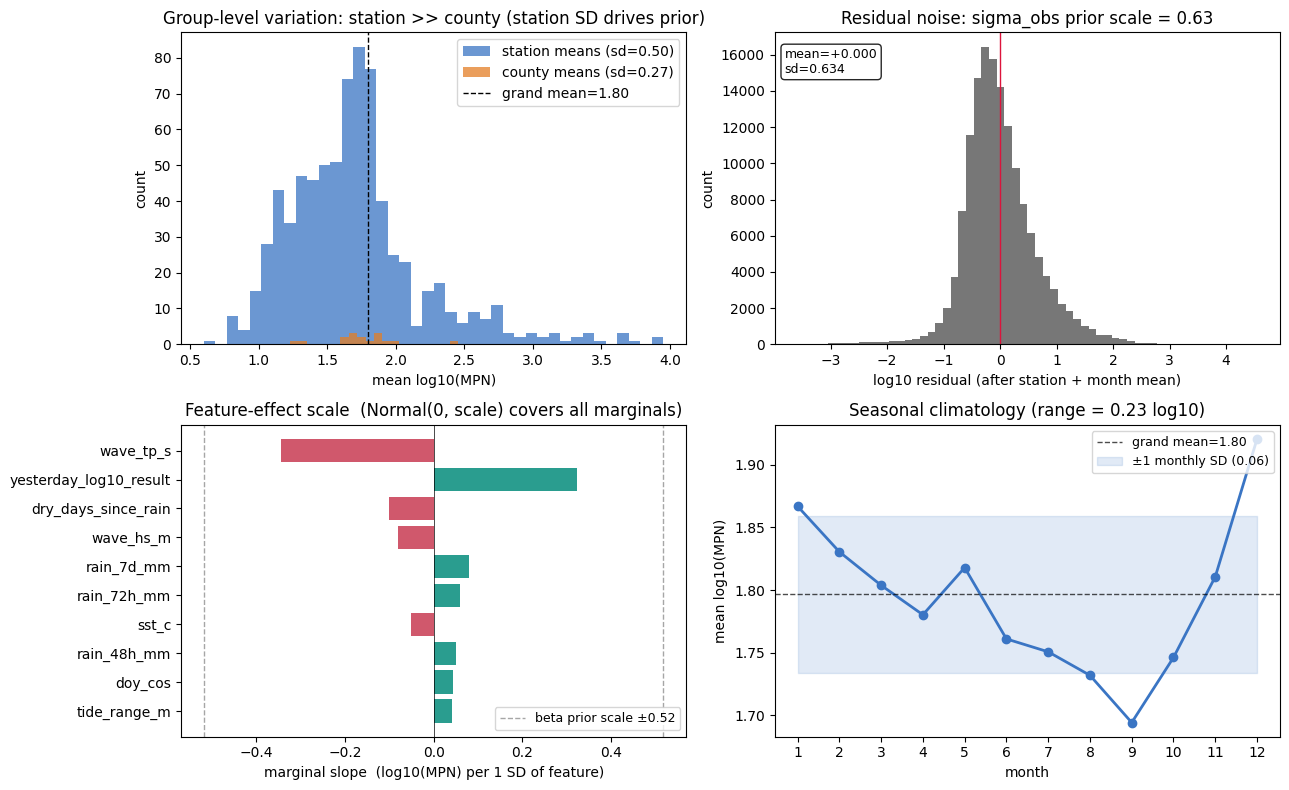


EMPIRICAL_PRIORS (serialized to enterococcus_panel_meta.json):
{
  "_computed_from": "interior observations (not left/right censored)",
  "_n_interior": 146626,
  "intercept": {
    "dist": "Normal",
    "loc": 1.796,
    "scale": 1.0
  },
  "alpha_month": {
    "dist": "Normal",
    "loc": 0.0,
    "scale": 0.1,
    "_note": "deviation of monthly mean from grand intercept; 12 non-centred levels"
  },
  "sigma_month": {
    "dist": "HalfNormal",
    "scale": 0.1,
    "_note": "hyperscale for the 12 month-level deviations (used when month enters as a random intercept)"
  },
  "sigma_station": {
    "dist": "HalfNormal",
    "scale": 0.495
  },
  "sigma_county": {
    "dist": "HalfNormal",
    "scale": 0.27
  },
  "sigma_obs": {
    "dist": "HalfNormal",
    "scale": 0.634
  },
  "beta_linear": {
    "dist": "Normal",
    "loc": 0.0,
    "scale": 0.517
  },
  "hsgp_amplitude_seasonal": {
    "dist": "HalfNormal",
    "scale": 0.1
  },
  "hsgp_amplitude_rain": {
    "dist": "HalfNormal",

In [14]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

obs = panel[panel["is_observed"]].copy()
interior = obs[~(obs["is_left_cens"].fillna(False) | obs["is_right_cens"].fillna(False))].copy()
y = interior["log10_result"].to_numpy(dtype=float)
n_interior = int(len(interior))

grand_mean = float(np.nanmean(y))
grand_sd   = float(np.nanstd(y))

_st_means = interior.groupby("Station_id")["log10_result"].mean()
_co_means = interior.groupby("CountyName")["log10_result"].mean()
sigma_station_emp = float(_st_means.std())
sigma_county_emp  = float(_co_means.std())

_st_mean_col = interior.groupby("Station_id")["log10_result"].transform("mean")
_month = interior["sample_date"].dt.month
_st_month_mean = (interior.assign(_m=_month)
                          .groupby(["Station_id", "_m"])["log10_result"]
                          .transform("mean"))
sigma_obs_after_station   = float((interior["log10_result"] - _st_mean_col).std())
sigma_obs_after_season    = float((interior["log10_result"] - _st_month_mean).std())

_z_cols = [f"{c}__z" for c in SMOOTH_FEATURES + LINEAR_FEATURES]
_z_cols = [c for c in _z_cols if c in interior.columns]
_slopes = []
for c in _z_cols:
    col = pd.to_numeric(interior[c], errors="coerce")
    mask = col.notna()
    if mask.sum() < 100 or col[mask].std() < 1e-8:
        continue
    r = float(np.corrcoef(col[mask], interior.loc[mask, "log10_result"])[0, 1])
    slope = r * (grand_sd / float(col[mask].std()))
    _slopes.append((c.replace("__z", ""), r, slope))
slopes_df = pd.DataFrame(_slopes, columns=["feature", "pearson_r", "slope_log10_per_sd"])
slopes_df = slopes_df.reindex(slopes_df["slope_log10_per_sd"].abs().sort_values(ascending=False).index)
max_abs_slope = float(slopes_df["slope_log10_per_sd"].abs().max()) if len(slopes_df) else 0.2
beta_prior_scale = float(max(0.5, 1.5 * max_abs_slope))

_monthly = interior.groupby(_month)["log10_result"].mean()
seasonal_sd = float(_monthly.std())
seasonal_range = float(_monthly.max() - _monthly.min())

if "regional_ghcn_prcp_mm" in interior.columns:
    _rain = interior["regional_ghcn_prcp_mm"].fillna(0).to_numpy(dtype=float)
    _m = _rain > 0
    if _m.sum() > 50:
        rain_slope = float(np.polyfit(np.log1p(_rain[_m]), y[_m], 1)[0])
    else:
        rain_slope = 0.0
else:
    rain_slope = 0.0

def _ar1(df: pd.DataFrame) -> float:
    s = df.sort_values(["Station_id", "sample_date"])
    prev = s.groupby("Station_id")["log10_result"].shift(1)
    m = prev.notna()
    if m.sum() < 50:
        return 0.0
    return float(np.corrcoef(s.loc[m, "log10_result"], prev[m])[0, 1])

ar1_within_station = _ar1(interior)

EMPIRICAL_PRIORS = {
    "_computed_from": "interior observations (not left/right censored)",
    "_n_interior": n_interior,
    "intercept":       {"dist": "Normal",     "loc": round(grand_mean, 3),           "scale": 1.0},
    "alpha_month":     {"dist": "Normal",     "loc": 0.0, "scale": round(max(seasonal_sd, 0.1), 3),
                        "_note": "deviation of monthly mean from grand intercept; 12 non-centred levels"},
    "sigma_month":     {"dist": "HalfNormal", "scale": round(max(seasonal_sd, 0.1), 3),
                        "_note": "hyperscale for the 12 month-level deviations (used when month enters as a random intercept)"},
    "sigma_station":   {"dist": "HalfNormal", "scale": round(sigma_station_emp, 3)},
    "sigma_county":    {"dist": "HalfNormal", "scale": round(sigma_county_emp,  3)},
    "sigma_obs":       {"dist": "HalfNormal", "scale": round(sigma_obs_after_season, 3)},
    "beta_linear":     {"dist": "Normal",     "loc": 0.0, "scale": round(beta_prior_scale, 3)},
    "hsgp_amplitude_seasonal": {"dist": "HalfNormal", "scale": round(max(seasonal_sd, 0.1), 3)},
    "hsgp_amplitude_rain":     {"dist": "HalfNormal", "scale": round(max(abs(rain_slope), 0.15), 3)},
    "_diagnostics": {
        "grand_sd": round(grand_sd, 3),
        "sigma_obs_after_station_only": round(sigma_obs_after_station, 3),
        "seasonal_range_log10": round(seasonal_range, 3),
        "rain_slope_log10_per_log1p_mm": round(rain_slope, 3),
        "ar1_within_station": round(ar1_within_station, 3),
        "max_abs_marginal_slope_per_sd": round(max_abs_slope, 3),
    },
}

print("=" * 74)
print(f"EMPIRICAL PRIOR ELICITATION   (n_interior = {n_interior:,})")
print("=" * 74)
print(f"{'parameter':<28s} {'dist':<11s} {'loc':>7s} {'scale':>8s}   role")
print("-" * 74)
_rows = [
    ("alpha_0 (intercept)",   EMPIRICAL_PRIORS["intercept"],              "baseline log10 MPN"),
    ("sigma_station",         EMPIRICAL_PRIORS["sigma_station"],          "between-station SD"),
    ("sigma_county",          EMPIRICAL_PRIORS["sigma_county"],           "between-county SD"),
    ("sigma_obs",             EMPIRICAL_PRIORS["sigma_obs"],              "residual log10 noise"),
    ("beta_k (linear)",       EMPIRICAL_PRIORS["beta_linear"],            "per z-scored feature"),
    ("seasonal smooth amp",   EMPIRICAL_PRIORS["hsgp_amplitude_seasonal"],"HSGP amplitude"),
    ("rain smooth amp",       EMPIRICAL_PRIORS["hsgp_amplitude_rain"],    "HSGP amplitude"),
]
for name, spec, role in _rows:
    loc = spec.get("loc", "")
    scl = spec.get("scale", "")
    print(f"{name:<28s} {spec['dist']:<11s} {str(loc):>7s} {str(scl):>8s}   {role}")

print()
print("marginal feature slopes (log10 per 1 SD of z-scored feature):")
print(slopes_df.to_string(index=False))
print()
print(f"lag-1 autocorrelation (within-station, interior rows): {ar1_within_station:+.3f}")
print("  -> day-to-day persistence is already carried by `yesterday_log10_result`;")
print("     do NOT add an explicit AR(1) term in the model (double counting).")

fig, ax = plt.subplots(2, 2, figsize=(13, 8))

ax[0, 0].hist(_st_means.to_numpy(), bins=40, color="#3a75c4", alpha=0.75,
              label=f"station means (sd={sigma_station_emp:.2f})")
ax[0, 0].hist(_co_means.to_numpy(), bins=20, color="#e37e25", alpha=0.75,
              label=f"county means (sd={sigma_county_emp:.2f})")
ax[0, 0].axvline(grand_mean, color="k", linestyle="--", lw=1,
                 label=f"grand mean={grand_mean:.2f}")
ax[0, 0].set_xlabel("mean log10(MPN)")
ax[0, 0].set_ylabel("count")
ax[0, 0].set_title("Group-level variation: station >> county (station SD drives prior)")
ax[0, 0].legend(loc="upper right")

_resid = (interior["log10_result"] - _st_month_mean).to_numpy()
ax[0, 1].hist(_resid, bins=60, color="#555", alpha=0.8)
ax[0, 1].axvline(0, color="crimson", lw=1)
ax[0, 1].set_xlabel("log10 residual (after station + month mean)")
ax[0, 1].set_ylabel("count")
ax[0, 1].set_title(f"Residual noise: sigma_obs prior scale = {sigma_obs_after_season:.2f}")
ax[0, 1].text(0.02, 0.95,
              f"mean={_resid[np.isfinite(_resid)].mean():+.3f}\nsd={sigma_obs_after_season:.3f}",
              transform=ax[0, 1].transAxes, va="top", fontsize=9,
              bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

_bar = slopes_df.head(10)
colors = ["#2a9d8f" if v >= 0 else "#d0586c" for v in _bar["slope_log10_per_sd"]]
ax[1, 0].barh(_bar["feature"], _bar["slope_log10_per_sd"], color=colors)
ax[1, 0].axvline(0, color="k", lw=0.5)
ax[1, 0].axvline(beta_prior_scale, color="gray", linestyle="--", lw=1, alpha=0.7)
ax[1, 0].axvline(-beta_prior_scale, color="gray", linestyle="--", lw=1, alpha=0.7,
                 label=f"beta prior scale ±{beta_prior_scale:.2f}")
ax[1, 0].invert_yaxis()
ax[1, 0].set_xlabel("marginal slope  (log10(MPN) per 1 SD of feature)")
ax[1, 0].set_title("Feature-effect scale  (Normal(0, scale) covers all marginals)")
ax[1, 0].legend(loc="lower right", fontsize=9)

_mon_ser = _monthly.reindex(range(1, 13))
ax[1, 1].plot(_mon_ser.index, _mon_ser.to_numpy(), "o-", color="#3a75c4", lw=2)
ax[1, 1].axhline(grand_mean, color="k", linestyle="--", lw=1, alpha=0.7,
                 label=f"grand mean={grand_mean:.2f}")
ax[1, 1].fill_between(_mon_ser.index, grand_mean - seasonal_sd, grand_mean + seasonal_sd,
                      color="#3a75c4", alpha=0.15, label=f"±1 monthly SD ({seasonal_sd:.2f})")
ax[1, 1].set_xticks(range(1, 13))
ax[1, 1].set_xlabel("month")
ax[1, 1].set_ylabel("mean log10(MPN)")
ax[1, 1].set_title(f"Seasonal climatology (range = {seasonal_range:.2f} log10)")
ax[1, 1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

print()
print("EMPIRICAL_PRIORS (serialized to enterococcus_panel_meta.json):")
print(json.dumps(EMPIRICAL_PRIORS, indent=2))


## 14. Count-space posterior preview (dry-run of the presentation layer)

Before fitting anything, this section previews **what a posterior prediction in MPN/100mL will actually look like** on your data, so the plot style and interval shape are vetted *before* a real model exists.

The model here is intentionally trivial — a station-specific log-normal fit with no predictors:

```
log10(y_ij) ~ Normal(mu_j, sigma_j)          (per-station fit)
mu_j | data ~ Normal(mu_hat_j, sigma_hat_j / sqrt(n_j))   (posterior of station mean)
y_new | data ~ Normal(mu_hat_j, sigma_hat_j * sqrt(1 + 1/n_j))   (posterior predictive)
```

That's it. No pooling, no covariates, no censoring adjustment. The real NumPyro model will be **tighter** (covariates explain variance, hierarchy borrows strength across stations, censoring is handled properly). If the raw per-station intervals already look plausible, the hierarchical version will look cleaner still.

What we're checking:

1. **Shape.** Intervals in MPN are asymmetric — that's correct. The lower band is compressed, the upper band stretches toward storm days. A symmetric-looking interval in MPN would signal a modeling error.
2. **Scale.** 80% bands spanning roughly an order of magnitude per station matches the log-noise regime we elicited (`sigma_obs ≈ 0.70`).
3. **Threshold crossing.** The 104 MPN advisory line cuts through the band at stations that routinely trigger postings, sits above the 80% band at clean beaches, and hovers inside the band at borderline beaches — exactly the operational signal `P(exceed)` is meant to capture.
4. **Median vs mean.** We print both for one beach to make Jensen's bias concrete — typical 2–3× upward inflation of the mean in MPN units for `sigma ≈ 0.7`.

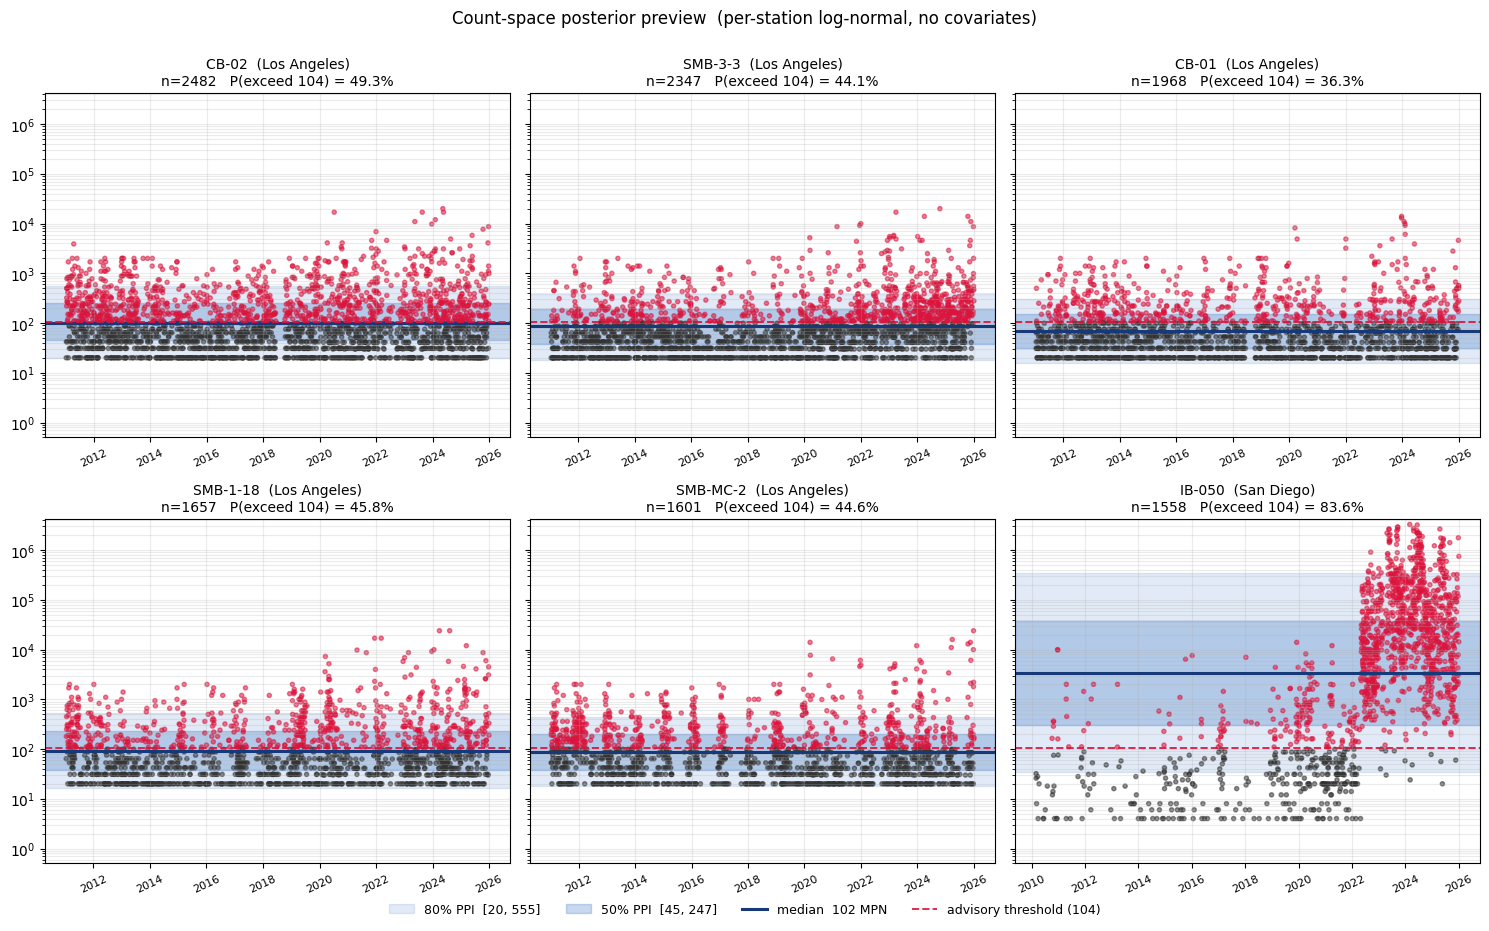


count-space posterior summary per station:
   beach      county    n  median MPN           50% PPI            80% PPI P(exc) empirical exc rate
   CB-02 Los Angeles 2482       101.9 [  45.0,   247.4]  [  19.7,   555.1]  49.3%              45.0%
 SMB-3-3 Los Angeles 2347        85.4 [  38.5,   188.6]  [  18.4,   389.3]  44.1%              35.7%
   CB-01 Los Angeles 1968        69.9 [  31.5,   153.2]  [  15.9,   305.2]  36.3%              29.2%
SMB-1-18 Los Angeles 1657        91.4 [  37.8,   226.0]  [  16.4,   525.0]  45.8%              40.6%
SMB-MC-2 Los Angeles 1601        86.6 [  37.8,   205.5]  [  17.8,   439.9]  44.6%              40.0%
  IB-050   San Diego 1558      3441.3 [ 299.6, 37525.9] [  34.4, 349329.5]  83.6%              77.5%

[Jensen's inequality demo — CB-02]
  posterior MEDIAN in counts (point estimate we should report):     101.9 MPN
  posterior MEAN   in counts (do NOT report as the prediction):     241.0 MPN
  ratio mean/median:  2.36x   (sigma_hat = 0.55, analytic

In [15]:
rng = np.random.default_rng(42)

log_exc = float(np.log10(EXCEEDANCE_MPN))

_label_col = "Station_Name" if interior["Station_Name"].notna().any() else "Station_id"
_counts = interior.groupby(["Station_id", _label_col, "CountyName"], dropna=False).size() \
                  .reset_index(name="n") \
                  .sort_values("n", ascending=False)
top = _counts[_counts["n"] >= 30].head(6).copy()


def fit_station(df_station: pd.DataFrame, n_draws: int = 5000) -> dict:
    y = df_station["log10_result"].to_numpy(dtype=float)
    y = y[np.isfinite(y)]
    n = len(y)
    mu_hat = float(y.mean())
    sd_hat = float(y.std(ddof=1)) if n > 1 else 0.5
    mu_draws = rng.normal(mu_hat, sd_hat / max(np.sqrt(n), 1.0), size=n_draws)
    y_pred = rng.normal(mu_draws, sd_hat * np.sqrt(1.0 + 1.0 / n), size=n_draws)
    counts_pred = 10 ** y_pred
    qs_log = np.quantile(y_pred, [0.10, 0.25, 0.50, 0.75, 0.90])
    return {
        "n": n,
        "mu_hat": mu_hat,
        "sd_hat": sd_hat,
        "median_mpn": float(10 ** qs_log[2]),
        "q10_mpn": float(10 ** qs_log[0]),
        "q25_mpn": float(10 ** qs_log[1]),
        "q75_mpn": float(10 ** qs_log[3]),
        "q90_mpn": float(10 ** qs_log[4]),
        "p_exceed": float(np.mean(y_pred > log_exc)),
        "mean_counts_jensen": float(counts_pred.mean()),
        "_y_pred_samples": y_pred,
        "_obs_y": y,
    }


fits = {}
for _, row in top.iterrows():
    sid = int(row["Station_id"])
    sub = interior[interior["Station_id"] == sid]
    fits[sid] = fit_station(sub)
    fits[sid]["_rows"] = sub
    fits[sid]["_label"] = str(row[_label_col]) if pd.notna(row[_label_col]) else f"Station {sid}"
    fits[sid]["_county"] = row["CountyName"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)
for ax, (sid, f) in zip(axes.flat, fits.items()):
    rows = f["_rows"]
    dates = rows["sample_date"].to_numpy()
    counts = (10 ** rows["log10_result"].to_numpy()).clip(0.5, None)

    ax.axhspan(f["q10_mpn"], f["q90_mpn"], color="#3a75c4", alpha=0.15,
               label=f"80% PPI  [{f['q10_mpn']:.0f}, {f['q90_mpn']:.0f}]")
    ax.axhspan(f["q25_mpn"], f["q75_mpn"], color="#3a75c4", alpha=0.28,
               label=f"50% PPI  [{f['q25_mpn']:.0f}, {f['q75_mpn']:.0f}]")
    ax.axhline(f["median_mpn"], color="#16397a", lw=2.2,
               label=f"median  {f['median_mpn']:.0f} MPN")
    ax.axhline(EXCEEDANCE_MPN, color="crimson", linestyle="--", lw=1.4, alpha=0.9,
               label=f"advisory threshold ({int(EXCEEDANCE_MPN)})")

    colors = np.where(counts > EXCEEDANCE_MPN, "crimson", "#333")
    ax.scatter(dates, counts, s=9, c=colors, alpha=0.55)

    ax.set_yscale("log")
    ax.set_ylim(0.5, max(counts.max() * 1.3, f["q90_mpn"] * 2))
    ax.set_title(
        f"{f['_label'][:36]}  ({f['_county']})\n"
        f"n={f['n']}   P(exceed 104) = {f['p_exceed']:.1%}",
        fontsize=10,
    )
    ax.grid(True, which="both", alpha=0.25)
    ax.tick_params(axis="x", rotation=25, labelsize=8)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.02), fontsize=9)
fig.suptitle("Count-space posterior preview  (per-station log-normal, no covariates)",
             y=1.00, fontsize=12)
plt.tight_layout()
plt.show()

_tbl = pd.DataFrame([
    {
        "beach": f["_label"][:34],
        "county": f["_county"],
        "n": f["n"],
        "median MPN":    round(f["median_mpn"], 1),
        "50% PPI":       f"[{f['q25_mpn']:>6.1f}, {f['q75_mpn']:>7.1f}]",
        "80% PPI":       f"[{f['q10_mpn']:>6.1f}, {f['q90_mpn']:>7.1f}]",
        "P(exc)":        f"{f['p_exceed']:>5.1%}",
        "empirical exc rate": f"{(10 ** f['_obs_y'] > EXCEEDANCE_MPN).mean():>5.1%}",
    }
    for f in fits.values()
])
print("\ncount-space posterior summary per station:")
print(_tbl.to_string(index=False))

_demo_sid = next(iter(fits))
_demo = fits[_demo_sid]
_naive_mean   = float(_demo["mean_counts_jensen"])
_median_point = float(_demo["median_mpn"])
_jensen_ratio = _naive_mean / _median_point
print()
print(f"[Jensen's inequality demo — {_demo['_label'][:30]}]")
print(f"  posterior MEDIAN in counts (point estimate we should report):  {_median_point:>8.1f} MPN")
print(f"  posterior MEAN   in counts (do NOT report as the prediction):  {_naive_mean:>8.1f} MPN")
print(f"  ratio mean/median:  {_jensen_ratio:.2f}x   "
      f"(sigma_hat = {_demo['sd_hat']:.2f}, analytic Jensen factor = "
      f"{np.exp((_demo['sd_hat'] * np.log(10)) ** 2 / 2):.2f}x)")
print("  These are both valid posterior summaries, but they answer different questions:")
print("    - median: 'what's the most likely count on a random day?'")
print("    - mean:   'if I had 1000 random days and summed, what's the average?'")
print("  For a dashboard, always show the median. Anything else misleads.")


## 15. Pack arrays for NumPyro / JAX

We expose exactly the pieces the model code needs:

- `station_idx : int32[N]` — integer index into `station_ids` (for station random effect)
- `county_idx  : int32[N]` — integer index into `county_names` (for county random effect)
- `t_idx       : int32[N]` — integer day index from `date_min` (for HSGP over time / AR(1))
- `X_smooth    : float32[N, Ks]` — standardized nonlinear inputs (HSGP smooths)
- `X_linear    : float32[N, Kl]` — standardized linear inputs
- `miss_smooth : int8[N, Ks]`, `miss_linear : int8[N, Kl]` — missingness indicators
- `y_log       : float32[N]` — log10 observed (NaN where unobserved)
- `obs_mask    : bool[N]` — True where a lab result exists
- `left_mask`, `right_mask : bool[N]` — censoring flags on observed rows
- `det_low_log`, `det_high_log : float32[N]` — log10 detection limits (NaN if not applicable)
- `split       : object[N]` — `"train" | "val" | "test"`

These are what the NumPyro model consumes. The censored likelihood looks like:
```
obs_center = y_log[obs_mask & ~left & ~right]
numpyro.sample("y", dist.Normal(eta_center, sigma_obs), obs=obs_center)
numpyro.factor("y_left",  dist.Normal(eta_left,  sigma_obs).cdf(det_low_log[left]).log().sum())
numpyro.factor("y_right", (1 - dist.Normal(eta_right, sigma_obs).cdf(det_high_log[right])).log().sum())
```
No modeling is run here, we just serialize the inputs.

In [16]:
def _pack_and_save_panel(panel: pd.DataFrame):
    station_ids = np.sort(panel["Station_id"].unique())
    station_to_idx = {sid: i for i, sid in enumerate(station_ids)}
    panel["station_idx"] = panel["Station_id"].map(station_to_idx).astype(np.int32)

    county_fill = panel["CountyName"].fillna("__unknown__")
    county_names = np.sort(county_fill.unique())
    county_to_idx = {c: i for i, c in enumerate(county_names)}
    panel["county_idx"] = county_fill.map(county_to_idx).astype(np.int32)

    date_min = panel["sample_date"].min()
    panel["t_idx"] = (panel["sample_date"] - date_min).dt.days.astype(np.int32)

    smooth_cols_z = [f"{c}__z" for c in SMOOTH_FEATURES]
    linear_cols_z = [f"{c}__z" for c in LINEAR_FEATURES]
    miss_smooth_cols = [f"{c}__missing" for c in SMOOTH_FEATURES]
    miss_linear_cols = [f"{c}__missing" for c in LINEAR_FEATURES]

    X_smooth = panel[smooth_cols_z].to_numpy(dtype=np.float32)
    X_linear = panel[linear_cols_z].to_numpy(dtype=np.float32)
    miss_smooth = panel[miss_smooth_cols].to_numpy(dtype=np.int8)
    miss_linear = panel[miss_linear_cols].to_numpy(dtype=np.int8)

    y_log = panel["log10_result"].to_numpy(dtype=np.float32)
    obs_mask = panel["is_observed"].to_numpy(dtype=bool)
    left_mask = panel["is_left_cens"].fillna(False).to_numpy(dtype=bool) & obs_mask
    right_mask = panel["is_right_cens"].fillna(False).to_numpy(dtype=bool) & obs_mask
    det_low_log = np.log10(panel["det_low"].to_numpy(dtype=float))
    det_high_log = np.log10(panel["det_high"].to_numpy(dtype=float))

    npz_path = OUT_DIR / "enterococcus_panel.npz"
    cv_val_year_arr = panel["cv_val_year"].to_numpy(np.int32) \
        if "cv_val_year" in panel.columns else np.zeros(len(panel), dtype=np.int32)
    station_names_arr = (panel.drop_duplicates("Station_id")
                              .sort_values("Station_id")["Station_Name"]
                              .fillna("")
                              .to_numpy(dtype=object)
                         if "Station_Name" in panel.columns
                         else np.full(len(station_ids), "", dtype=object))

    np.savez_compressed(
        npz_path,
        station_idx=panel["station_idx"].to_numpy(np.int32),
        county_idx=panel["county_idx"].to_numpy(np.int32),
        t_idx=panel["t_idx"].to_numpy(np.int32),
        X_smooth=X_smooth,
        X_linear=X_linear,
        miss_smooth=miss_smooth,
        miss_linear=miss_linear,
        y_log=y_log,
        obs_mask=obs_mask,
        left_mask=left_mask,
        right_mask=right_mask,
        det_low_log=det_low_log,
        det_high_log=det_high_log,
        cv_val_year=cv_val_year_arr,
        station_ids=station_ids.astype(np.int64),
        station_names=station_names_arr,
        county_names=np.asarray(county_names, dtype=object),
        smooth_features=np.asarray(SMOOTH_FEATURES, dtype=object),
        linear_features=np.asarray(LINEAR_FEATURES, dtype=object),
        date_min=np.datetime64(date_min.to_pydatetime().date()),
    )

    panel_to_write = panel.copy()
    panel_to_write["Station_id"] = panel_to_write["Station_id"].astype("int64")
    for c in panel_to_write.columns:
        if pd.api.types.is_extension_array_dtype(panel_to_write[c].dtype):
            panel_to_write[c] = panel_to_write[c].astype(object)

    panel_pickle = OUT_DIR / "enterococcus_panel.pkl"
    panel_to_write.to_pickle(panel_pickle)
    panel_path = panel_pickle
    try:
        parquet_target = OUT_DIR / "enterococcus_panel.parquet"
        panel_to_write.to_parquet(parquet_target, index=False)
        panel_path = parquet_target
    except Exception as exc:
        print(f"[warn] parquet write skipped (falling back to pickle): {exc.__class__.__name__}: {exc}")

    meta_out = {
        "target_parameter": TARGET_PARAMETER,
        "exceedance_mpn": EXCEEDANCE_MPN,
        "train_end": str(TRAIN_END.date()),
        "val_end": str(VAL_END.date()),
        "n_rows": int(len(panel)),
        "n_observed": int(obs_mask.sum()),
        "n_left_cens": int(left_mask.sum()),
        "n_right_cens": int(right_mask.sum()),
        "n_stations": int(len(station_ids)),
        "n_counties": int(len(county_names)),
        "smooth_features": SMOOTH_FEATURES,
        "linear_features": LINEAR_FEATURES,
        "scalers": scalers,
        "date_min": str(date_min.date()),
        "date_max": str(panel["sample_date"].max().date()),
        "cv_scheme": "expanding_window_rolling_origin",
        "cv_val_years": list(CV_VAL_YEARS),
        "cv_folds": CV_FOLDS,
        "station_labels_cache": str(STATION_LABELS_PATH.relative_to(REPO))
        if STATION_LABELS_PATH.exists() else None,
        "n_stations_with_name": int(panel["Station_Name"].notna().sum() > 0
                                     and panel.drop_duplicates("Station_id")["Station_Name"].notna().sum()),
        "priors": globals().get("EMPIRICAL_PRIORS"),
    }
    (OUT_DIR / "enterococcus_panel_meta.json").write_text(json.dumps(meta_out, indent=2, default=str))

    return npz_path, panel_path, station_ids, county_names, obs_mask, left_mask, right_mask


npz_path, panel_path, station_ids, county_names, obs_mask, left_mask, right_mask = _pack_and_save_panel(panel)
tag = "rebuild" if REBUILD else "reload-repack"
print(f"[{tag}] wrote:")
print(" ", npz_path.relative_to(REPO))
print(" ", panel_path.relative_to(REPO))
print(" ", (OUT_DIR / "enterococcus_panel_meta.json").relative_to(REPO))


[rebuild] wrote:
  artifacts/data/panel/enterococcus_panel.npz
  artifacts/data/panel/enterococcus_panel.parquet
  artifacts/data/panel/enterococcus_panel_meta.json


## 16. Final shape check

Quick inspection of the packed arrays so any model notebook downstream can `np.load(...)` with confidence.

In [17]:
print(f"npz  : {npz_path.relative_to(REPO)}  ({npz_path.stat().st_size/1e6:.2f} MB)")
print(f"panel: {panel_path.relative_to(REPO)}  ({panel_path.stat().st_size/1e6:.2f} MB)")
print()

with np.load(npz_path, allow_pickle=True) as z:
    for k in z.files:
        a = z[k]
        if hasattr(a, "shape") and getattr(a, "dtype", None) is not None:
            print(f"{k:>18s} : shape={a.shape} dtype={a.dtype}")
        else:
            print(f"{k:>18s} : {a!r}")

print("\nRound-trip load of saved panel:")
if panel_path.suffix == ".parquet":
    panel_reloaded = read_parquet_safe(panel_path)
    panel_reloaded["sample_date"] = pd.to_datetime(panel_reloaded["sample_date"])
else:
    panel_reloaded = pd.read_pickle(panel_path)
print(f"  rows={len(panel_reloaded):,}  cols={panel_reloaded.shape[1]}")

print("\nSplit sanity:")
print(panel.groupby("split").agg(n=("sample_date", "size"),
                                  observed=("is_observed", "sum"),
                                  left=("is_left_cens", "sum"),
                                  right=("is_right_cens", "sum")))

npz  : artifacts/data/panel/enterococcus_panel.npz  (5.53 MB)
panel: artifacts/data/panel/enterococcus_panel.parquet  (22.94 MB)

       station_idx : shape=(3173957,) dtype=int32
        county_idx : shape=(3173957,) dtype=int32
             t_idx : shape=(3173957,) dtype=int32
          X_smooth : shape=(3173957, 9) dtype=float32
          X_linear : shape=(3173957, 4) dtype=float32
       miss_smooth : shape=(3173957, 9) dtype=int8
       miss_linear : shape=(3173957, 4) dtype=int8
             y_log : shape=(3173957,) dtype=float32
          obs_mask : shape=(3173957,) dtype=bool
         left_mask : shape=(3173957,) dtype=bool
        right_mask : shape=(3173957,) dtype=bool
       det_low_log : shape=(3173957,) dtype=float64
      det_high_log : shape=(3173957,) dtype=float64
       cv_val_year : shape=(3173957,) dtype=int32
       station_ids : shape=(778,) dtype=int64
     station_names : shape=(778,) dtype=object
      county_names : shape=(16,) dtype=object
   smooth_features